<a href="https://colab.research.google.com/github/AswiniAnnieMathew/MXN441-Assignment2/blob/main/MXN441Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MXN441 Assignment 2**

## **Selected Paper:**

### **Objective:** To assess the accuracy of using simpler ML models with only high-impact predictors compared to the use of all predictors, and to evaluate whether the resulting computational savings and reduced data collection requirements are valuable for practical implementation in various industries.

### Submitted By:

### Aswini Annie Mathew

### Aum Chantapimpa

In [2]:
# load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from scipy.stats import uniform, randint

import xgboost as xgb
import os
from google.colab import userdata
import shutil
import joblib


In [3]:
import os
from google.colab import userdata

# GitHub Configuration
GITHUB_USER = "AswiniAnnieMathew"
GITHUB_REPO = "MXN441-Assignment2"

# # Retrieve GitHub token from Colab's Secrets Manager
# token = userdata.get('GITHUB_TOKEN')

# **Dataset Overview**

In [4]:
import pandas as pd

# load data
df_backorder_raw = pd.read_csv("https://raw.githubusercontent.com/AswiniAnnieMathew/MXN441-Assignment2/main/Data/Training_Dataset_v2.csv")

In [5]:
# inspect data
df_backorder_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 23 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   sku                1048575 non-null  int64  
 1   national_inv       1048575 non-null  int64  
 2   lead_time          984057 non-null   float64
 3   in_transit_qty     1048575 non-null  int64  
 4   forecast_3_month   1048575 non-null  int64  
 5   forecast_6_month   1048575 non-null  int64  
 6   forecast_9_month   1048575 non-null  int64  
 7   sales_1_month      1048575 non-null  int64  
 8   sales_3_month      1048575 non-null  int64  
 9   sales_6_month      1048575 non-null  int64  
 10  sales_9_month      1048575 non-null  int64  
 11  min_bank           1048575 non-null  int64  
 12  potential_issue    1048575 non-null  object 
 13  pieces_past_due    1048575 non-null  int64  
 14  perf_6_month_avg   1048575 non-null  float64
 15  perf_12_month_avg  1048575 non-n

The initial inspection shows 23 columns. There are 16 numerical columns and 7 objects. The only column with missing value is lead_time.

## **Variable Description**

Variables used in this dataset are described below:

sku: Unique product ID

national_inv: Current stock level

lead_time: Supplier lead time

in_transit_qty: Quantity in transit

forecast_3_month: Forecasted sales over the next 3 months.

forecast_6_month: Forecasted sales over the next 6 months.

forecast_9_month: Forecasted sales over the next 9 months.

sales_1_month: Actual sales over the past 1 month.

sales_3_month: Actual sales over the past 3 months.

sales_6_month: Actual sales over the past 6 months.

sales_9_month: Actual sales over the past 9 months.

min_bank: Minimum stock level

perf_6_month_avg: Source performance average over the past 6 months, expressed as percentage between 0 and 1

perf_12_month_avg: Source performance average over the past 12 months, expressed as percentage between 0 and 1

local_bo_qty: Local backorder quantity

pieces_past_due: Quantity past the due date from supplier

potential_issue: Binary Yes or No risk indicator

deck_risk: Binary Yes or No risk indicator

oe_constraint: Binary Yes or No risk indicator

ppap_risk: Binary Yes or No risk indicator

stop_auto_buy: Binary Yes or No risk indicator

rev_stop: Binary Yes or No risk indicator

went_on_backorder: Yes or No to indicate if the product went on backorder.

## **Descriptive Analytics**

### **Checking Missing Values**

In [6]:
# Check missing values across all columns
Check_missing_data = df_backorder_raw.isnull().sum()
proportion = (Check_missing_data / len(df_backorder_raw)) * 100
missing_summary = pd.DataFrame({
    'missing_count': Check_missing_data,
    'missing_pct': proportion.round(3)
})
display(missing_summary[missing_summary['missing_count'] > 0])

,missing_count,missing_pct
lead_time,64518,6.153


The column, lead_time is missing values for 6% of total rows.

### **Descriptive Summary**

In [7]:
df_backorder_raw.describe().loc[['mean', '50%', 'std', 'min', 'max']]\
                           .rename(index={'50%': 'median'})\
                           .T.round(2)

,mean,median,std,min,max
sku,1773693.32,1810846.00,399577.24,1026827.0,3284914.0
national_inv,489.42,15.00,28595.83,-13491.0,12334404.0
lead_time,7.84,8.00,7.04,0.0,52.0
in_transit_qty,45.36,0.00,1390.54,0.0,489408.0
forecast_3_month,185.23,0.00,5032.30,0.0,1218328.0
forecast_6_month,360.88,0.00,10067.64,0.0,2461360.0
forecast_9_month,528.91,0.00,14895.45,0.0,3777304.0
sales_1_month,57.30,0.00,2067.93,0.0,741774.0
sales_3_month,180.46,1.00,5263.48,0.0,1094112.0
sales_6_month,352.46,2.00,9773.35,0.0,2146625.0


The statistics clearly shows that most of the columns related to sales and forecasts are heavily right skewed which means majority of the products sell in small quantities but a few sell enormously.

### **Numerical Variable Analysis**

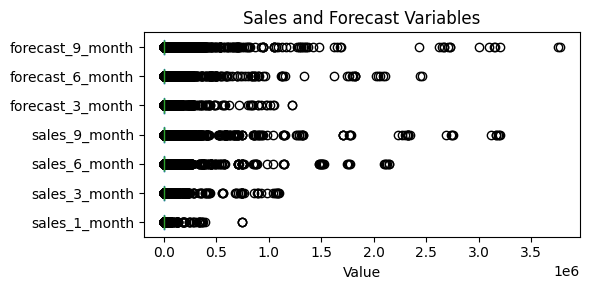

In [8]:
import matplotlib.pyplot as plt
# Group columns by similar scales for readable plots
sales_forecast = ['sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month',
                  'forecast_3_month', 'forecast_6_month', 'forecast_9_month']
fig, ax = plt.subplots(1, 1, figsize=(6, 3))

df_backorder_raw[sales_forecast].plot(kind='box', vert=False, ax=ax)
ax.set_title('Sales and Forecast Variables')
ax.set_xlabel('Value')
plt.tight_layout()
plt.show()

The current inventory level and performace average shows negative values and understanding these further by looking at the data.

In [9]:

# Display settings
pd.set_option('display.max_rows', 50)
df_backorder_raw[df_backorder_raw['national_inv']< 0]

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
176,1111655,-55,8.0,2,428,526,606,25,100,205,...,0,-99.00,-99.00,56,No,No,No,Yes,No,Yes
191,1111670,-499,12.0,350,3452,5044,7188,747,2550,3572,...,0,0.49,0.72,525,No,No,No,Yes,No,Yes
342,1111821,-48,8.0,97,67,85,115,19,87,165,...,0,0.47,0.47,60,Yes,No,No,Yes,No,No
552,1112031,-1,12.0,0,6,6,6,0,1,2,...,0,0.82,0.79,1,No,No,No,Yes,No,No
916,1112396,-94,9.0,80,5,8,8,205,205,205,...,0,0.91,0.74,0,No,No,No,Yes,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039749,1398295,-4,NaN,0,0,0,0,0,9,25,...,0,-99.00,-99.00,0,No,No,No,No,No,No
1039835,1398384,-85,12.0,0,126,126,126,0,110,141,...,0,0.00,0.01,0,No,No,No,Yes,No,Yes
1040249,1398825,-6,NaN,0,0,0,0,3,14,49,...,0,-99.00,-99.00,0,No,No,Yes,Yes,No,No
1042276,1400992,-2,NaN,7,0,0,0,4,21,44,...,0,-99.00,-99.00,3,No,No,No,No,No,No


Analysing the relationship between national_inv < 0 and the went_on_backorder column.

In [10]:
# Analyze products with negative national inventory
negative_inventory_rows = df_backorder_raw[df_backorder_raw['national_inv'] < 0]
total_neg_inv_count = negative_inventory_rows.shape[0]

neg_inv_backorder_yes = negative_inventory_rows[negative_inventory_rows['went_on_backorder'] == 'Yes'].shape[0]
neg_inv_backorder_no = negative_inventory_rows[negative_inventory_rows['went_on_backorder'] == 'No'].shape[0]

percentage_neg_inv_backorder_yes = np.round((neg_inv_backorder_yes / total_neg_inv_count * 100), 2)
percentage_neg_inv_backorder_no = np.round((neg_inv_backorder_no / total_neg_inv_count * 100), 2)

print("Negative inventory Level Details\n")
print("Total rows with negative inventory: ",total_neg_inv_count)
print("Went on backorder:", neg_inv_backorder_yes, "(",percentage_neg_inv_backorder_yes, "%)")
print("Did not go on backorder:", neg_inv_backorder_no, "(",percentage_neg_inv_backorder_no, "%)","\n")

pos_inv_backorder_yes = df_backorder_raw[(df_backorder_raw['national_inv'] >= 0) & (df_backorder_raw['went_on_backorder'] == 'Yes')].shape[0]
print("Non-Negative inventory backorders \n")
print("Products with national_inv >= 0 that went on backorder:", pos_inv_backorder_yes,"\n")

total_dataset_rows = df_backorder_raw.shape[0]
total_backorders = neg_inv_backorder_yes + pos_inv_backorder_yes
overall_backorder_rate = np.round((total_backorders / total_dataset_rows * 100), 4)

print("Overall dataset\n")
print("Total rows in dataset:", total_dataset_rows)
print("Total backorders", total_backorders)
print("Overall backorder rate:", overall_backorder_rate)

print("\nComparison of backorder rates\n")
print("Backorder rate for Negative Inventory products:", percentage_neg_inv_backorder_yes,"%")
total_non_neg_inv_rows = total_dataset_rows - total_neg_inv_count
non_neg_inv_backorder_rate = np.round((pos_inv_backorder_yes / total_non_neg_inv_rows * 100), 4)
print("Backorder rate for Non-Negative Inventory products:", non_neg_inv_backorder_rate,"%")


Negative inventory Level Details

Total rows with negative inventory:  3785
Went on backorder: 678 ( 17.91 %)
Did not go on backorder: 3107 ( 82.09 %) 

Non-Negative inventory backorders 

Products with national_inv >= 0 that went on backorder: 8222 

Overall dataset

Total rows in dataset: 1048575
Total backorders 8900
Overall backorder rate: 0.8488

Comparison of backorder rates

Backorder rate for Negative Inventory products: 17.91 %
Backorder rate for Non-Negative Inventory products: 0.787 %


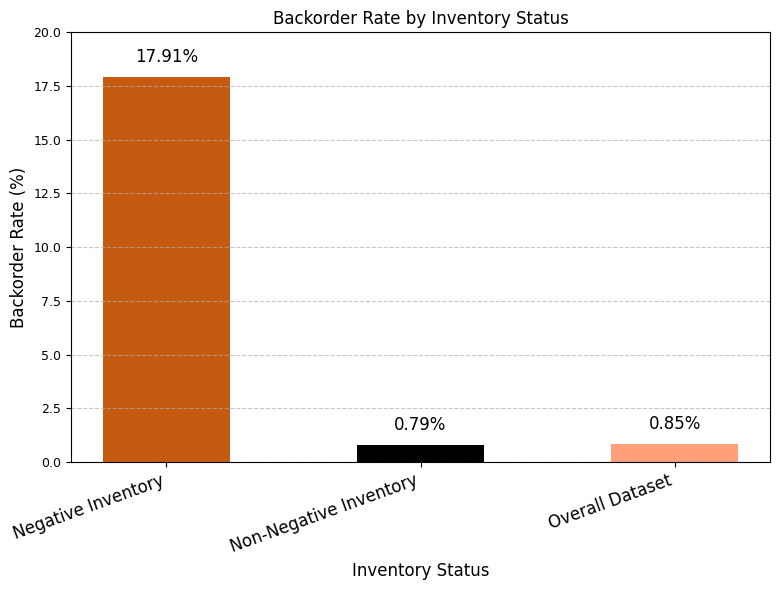

In [11]:
# Data extracted from the output
data = {
    'Inventory Status': ['Negative Inventory', 'Non-Negative Inventory', 'Overall Dataset'],
    'Backorder Rate (%)': [17.91, 0.787, 0.8488]
}

df_backorder_rates = pd.DataFrame(data)

# Define colors for the bars
colors = ['#C55A11', 'black', '#FFA07A']

plt.figure(figsize=(8, 6)) # figure size
plt.bar(df_backorder_rates['Inventory Status'], df_backorder_rates['Backorder Rate (%)'], color=colors, width=0.5) # Reduced bar width

plt.title('Backorder Rate by Inventory Status', fontsize=12, y=1)
plt.xlabel('Inventory Status', fontsize=12)
plt.ylabel('Backorder Rate (%)', fontsize=12)
plt.xticks(rotation=20, ha='right', fontsize=12)
plt.yticks(fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 20) # Set y-axis limit to 30

# Annotate bars with their values
for i, row in df_backorder_rates.iterrows():
    plt.text(i, row['Backorder Rate (%)'] + 0.5, f"{row['Backorder Rate (%)']:.2f}%", color='black', ha="center", va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

The above analysis shows that Negative Invetory levels are ~22 times more likely to go on backorder. These negative inventory levels analysis shows that most of the at-risk products are fulfilled before going to backorder


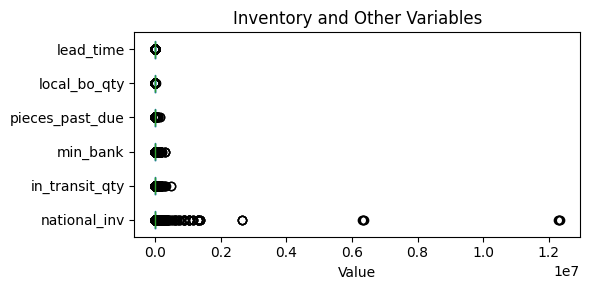

In [12]:
inv = ['national_inv', 'in_transit_qty', 'min_bank',
       'pieces_past_due', 'local_bo_qty', 'lead_time']

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
df_backorder_raw[inv].plot(kind='box', vert=False, ax=ax)
ax.set_title('Inventory and Other Variables')
ax.set_xlabel('Value')

plt.tight_layout()
plt.show()

The above box plot also shows some extreme in stock quantities for certain products.

Analysing the negative values in perf_6_month_avg, perf_12_month_avg

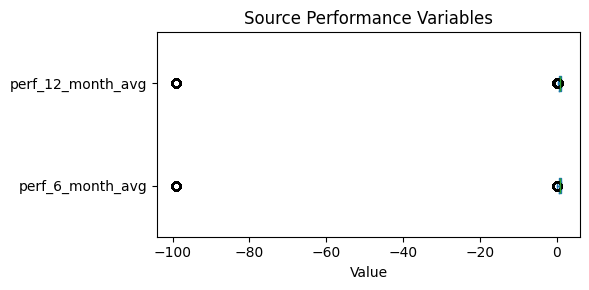

In [13]:
perf = ['perf_6_month_avg', 'perf_12_month_avg']
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
df_backorder_raw[perf].plot(kind='box', vert=False, ax=ax)
ax.set_title('Source Performance Variables')
ax.set_xlabel('Value')
plt.tight_layout()
plt.show()

No rows between 0 and -99 and some rows are exactly -99. Most of values are concentrated between 0 and 1 with a maximum vlaue of 1. This strongly suggests that the isolated -99 value is a code for may be a missing or unkown value and not a measurement. The median is not impacted by extreme outliers and a value of around 0.80 indicates most of the suppliers are reliable.

### **Categorical Variable Analysis**

For each risk flag, we analyzed the proportion of flagged items that actually resulted in a backorder state

In [14]:
cat_predictors = ['potential_issue', 'deck_risk', 'oe_constraint',
                  'ppap_risk', 'stop_auto_buy', 'rev_stop']
for col in cat_predictors:
    print("\nAnalysis for: ", col, "\n")
    # Create cross-tab
    ct = pd.crosstab(df_backorder_raw[col], df_backorder_raw['went_on_backorder'], margins=True, margins_name="Total")

    # Calculate percentages for both 'No' and 'Yes' outcomes
    ct_pct = ct.div(ct['Total'], axis=0).multiply(100).round(2)

    # Combine counts and percentages for a clear view
    combined = pd.concat([ct, ct_pct.rename(columns={'No': 'No (%)', 'Yes': 'Yes (%)'})[['No (%)', 'Yes (%)']]], axis=1)

    display(combined[['No', 'No (%)', 'Yes', 'Yes (%)', 'Total']])


Analysis for:  potential_issue 



went_on_backorder,No,No (%),Yes,Yes (%),Total
potential_issue,,,,,
No,1039042,99.15,8861,0.85,1047903
Yes,633,94.20,39,5.80,672
Total,1039675,99.15,8900,0.85,1048575



Analysis for:  deck_risk 



went_on_backorder,No,No (%),Yes,Yes (%),Total
deck_risk,,,,,
No,788209,99.08,7349,0.92,795558
Yes,251466,99.39,1551,0.61,253017
Total,1039675,99.15,8900,0.85,1048575



Analysis for:  oe_constraint 



...

went_on_backorder,No,No (%),Yes,Yes (%),Total
ppap_risk,,,,,
No,913616,99.19,7495,0.81,921111
Yes,126059,98.90,1405,1.10,127464
Total,1039675,99.15,8900,0.85,1048575



Analysis for:  stop_auto_buy 



went_on_backorder,No,No (%),Yes,Yes (%),Total
stop_auto_buy,,,,,
No,36585,99.05,351,0.95,36936
Yes,1003090,99.15,8549,0.85,1011639
Total,1039675,99.15,8900,0.85,1048575



Analysis for:  rev_stop 



went_on_backorder,No,No (%),Yes,Yes (%),Total
rev_stop,,,,,
No,1039217,99.15,8900,0.85,1048117
Yes,458,100.00,0,0.00,458
Total,1039675,99.15,8900,0.85,1048575


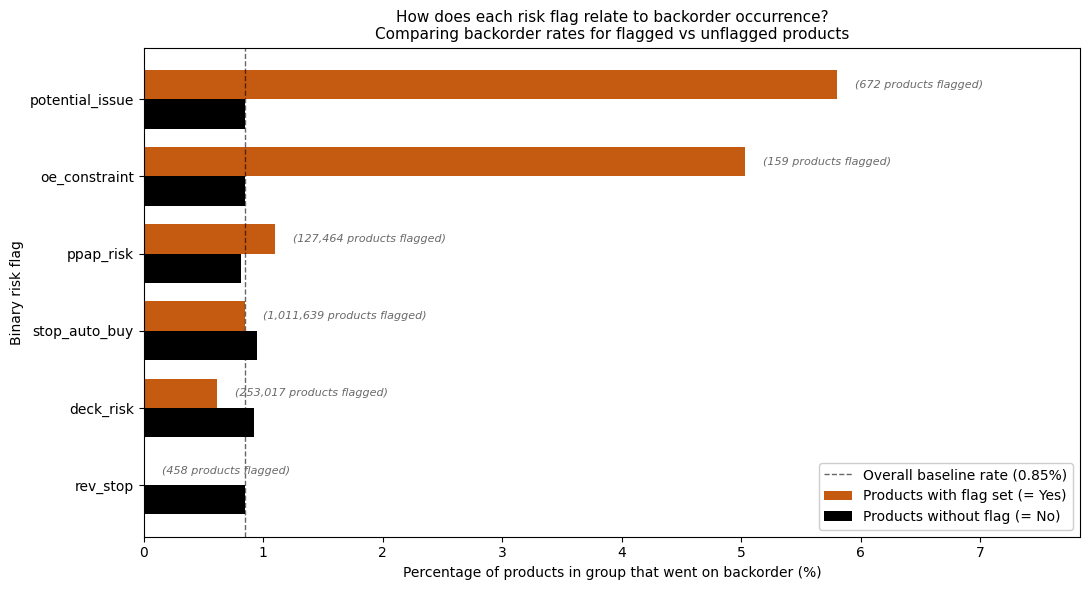

In [15]:
cat_predictors = ['potential_issue', 'deck_risk', 'oe_constraint',
                  'ppap_risk', 'stop_auto_buy', 'rev_stop']

results = []
for col in cat_predictors:
    ct = pd.crosstab(df_backorder_raw[col], df_backorder_raw['went_on_backorder'])
    rate_yes = ct.loc['Yes', 'Yes'] / ct.loc['Yes'].sum() * 100 if 'Yes' in ct.index else 0
    rate_no  = ct.loc['No',  'Yes'] / ct.loc['No'].sum()  * 100 if 'No'  in ct.index else 0
    count_yes = ct.loc['Yes'].sum() if 'Yes' in ct.index else 0
    results.append({'flag': col, 'rate_yes': rate_yes, 'rate_no': rate_no, 'count_yes': count_yes})

results_df = pd.DataFrame(results).sort_values('rate_yes', ascending=False).reset_index(drop=True)
baseline = (df_backorder_raw['went_on_backorder'] == 'Yes').mean() * 100

fig, ax = plt.subplots(figsize=(11, 6))
y_pos = np.arange(len(results_df))
height = 0.38

ax.barh(y_pos - height/2, results_df['rate_yes'], height,
        label='Products with flag set (= Yes)', color='#C55A11')
ax.barh(y_pos + height/2, results_df['rate_no'], height,
        label='Products without flag (= No)', color='black')

ax.axvline(baseline, color='black', linestyle='--', linewidth=1, alpha=0.6,
           label=f'Overall baseline rate ({baseline:.2f}%)')

# Show row count only on the Yes bars
for i, row in results_df.iterrows():
    ax.text(row['rate_yes'] + 0.15, i - height/2,
            f"({int(row['count_yes']):,} products flagged)",
            va='center', fontsize=8, color='dimgray', style='italic')

ax.set_yticks(y_pos)
ax.set_yticklabels(results_df['flag'])
ax.set_xlabel('Percentage of products in group that went on backorder (%)')
ax.set_ylabel('Binary risk flag')
ax.set_title('How does each risk flag relate to backorder occurrence?\n'
             'Comparing backorder rates for flagged vs unflagged products',
             fontsize=11)
ax.legend(loc='lower right', framealpha=0.95)
ax.invert_yaxis()
ax.set_xlim(0, max(results_df['rate_yes']) * 1.35)  # headroom for annotations

plt.tight_layout()
plt.show()

The above chart shows all six binary predictors ordered top to down from most predictive to least predictive. The X axis represents the percentage of products that went on backorder within each indicators. The dotted line represents overall backorder rate in the dataset.

Potential_issue: Out of 672 products that have a potential_issue, 5.8% went on backorder. And of all products without a potential issue, 0.85% went on backorder. This means products flagged with potential_issue are about 6.8 times more likely to backorder than an unflagged product.
oe_constraint: Same as above. 5.9 times more likely to backorder than an unflagged product. However both predictors have small flagged subset  and therefore limits how much overall signal these contribute.

deck_risk: The products that are flagged with deck_risk is associated with lower backorder risk. This may be due to close monitoring or careful operational handling.

rev_stop: rev_stop can mean the products are blocked for sale due to revenue reason and therefore as data shows, they might be excluded from normal order fufilment.

stop_auto_buy: for most of the products this feature has been enabled and there is not much influence on the target variable.

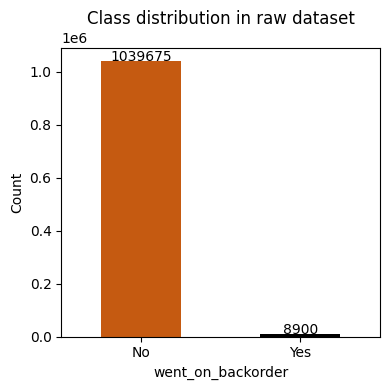


Class balance: 0.85 % Yes, 99.15 % No


In [16]:
# check class imbalance in the target variable
target_counts = df_backorder_raw['went_on_backorder'].value_counts()
total = len(df_backorder_raw)

fig, ax = plt.subplots(figsize=(4, 4))
target_counts.plot(kind='bar', color=['#C55A11', 'black'], ax=ax)
ax.set_title('Class distribution in raw dataset')
ax.set_xlabel('went_on_backorder')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)

# Annotate each bar with its count
for i in range(len(target_counts)):
    ax.text(i, target_counts.iloc[i] + 50, str(target_counts.iloc[i]), ha='center')

plt.tight_layout()
plt.show()

print("\nClass balance:",
      round(target_counts['Yes'] / total * 100, 2), "% Yes,",
      round(target_counts['No'] / total * 100, 2), "% No")

The dataset is severely imbalanced only ~0.85% of products went
on backorder. The paper addresses this with random downsampling, which
we will apply later.

## **Summary of Analysis**

1. The -99 code in perf_6_month_avg and perf_12_month_avg

    Preprocessing Recommended:
    Replace -99 with NaN so subsequent operations recognise it as missing.
    Create a missing-indicator column. After splitting train/test, impute NaNs with the training-set median of each column.

2. NaN values in lead_time

    Preprocessing Recommended:
    Add a lead_time_was_missing indicator
    Impute with the training-set median.

3. Negative national_inv values

    Preprocessing Recommended:
    Leave the negative values alone as they are operationally meaningful and not errors.

4. Extreme right-skew in sales, forecast, and inventory variables

    Preprocessing Recommended:
    For linear models like Logistic Regression, apply log1p transformation which handles zeros.
    For tree-based models: no transformation needed. Trees are scale invariant and handle skew natively.

5. Massive scale disparity between features

    Preprocessing:
    standardisation is essential.

6. Binary categorical flags

    Preprocessing:
    Encode as 0/1 integers

7. SKU column is just an identifier:
    Means and stds of SKU are meaningless.

    Preprocessing:
    Drop the column before modelling.

8. Severe class imbalance
    Preprocessing:
    the paper used random downsampling


9. Target variable as Yes/No strings: went_on_backorder is stored as Yes/No.

    Preprocessing:
    Encode as 0/1

# **Methodology**

## **Preprocessing**

We can make several improvements to the paper in preprocessing steps as well as dealing with class imbalances.

However, we are replicating the same preprocessing steps as implemented in the paper.

1. Drop sku column
2. Encode 6 binary flags
3. Encode target variable
4. Drop rows with NaN in lead_time - Paper Choice
5. Paper doesn't mention about -99 code in perf columns. So we also kept these values in the dataset.
6. Random downsample training set to balance classes - Paper's choice to do downsampling before split
7. Create Dataset 1 - 22 Features
8. Create Dataset 2 - 5 fetaures: national_inv, forecast_3_month, forecast_6_month, sales_9_month, perf_6_month_avg (selected based on feature importance rankings from prior literature: Adana et al. 2019; Gao et al. 2022; Islam & Amin 2020; Ntakolia et al. 2021; Shajalal et al. 2022)


### **Dropping SKU Column**

In [17]:
# Dropping SKU Column
df_backorder_preprocessed = df_backorder_raw.copy()
df_backorder_preprocessed.drop('sku', axis=1, inplace=True)

### **Encode all categorical variables**

In [18]:
# Encode all categorical variables
categorical_cols = ['potential_issue', 'deck_risk', 'oe_constraint',
                    'ppap_risk', 'stop_auto_buy', 'rev_stop',
                    'went_on_backorder']

for col in categorical_cols:
    df_backorder_preprocessed[col] = df_backorder_preprocessed[col].map({'Yes': 1, 'No': 0})

print("After encoding:")
print(df_backorder_preprocessed[categorical_cols].head())
print(f"\nDtypes:\n{df_backorder_preprocessed.dtypes}")

After encoding:
   potential_issue  deck_risk  oe_constraint  ppap_risk  stop_auto_buy  \
0                0          0              0          0              1   
1                0          0              0          0              1   
2                0          1              0          0              1   
3                0          0              0          0              1   
4                0          1              0          0              1   

   rev_stop  went_on_backorder  
0         0                  0  
1         0                  0  
2         0                  0  
3         0                  0  
4         0                  0  

Dtypes:
national_inv           int64
lead_time            float64
in_transit_qty         int64
forecast_3_month       int64
forecast_6_month       int64
forecast_9_month       int64
sales_1_month          int64
sales_3_month          int64
sales_6_month          int64
sales_9_month          int64
min_bank               int64
potential_iss

### **Drop rows with NaN in lead_time**

In [19]:
# Drop rows with NaN in lead_time - Paper Choice
n_before = len(df_backorder_preprocessed)
df_backorder_preprocessed.dropna(subset=['lead_time'], inplace=True)
df_backorder_preprocessed.reset_index(drop=True, inplace=True)
n_after = len(df_backorder_preprocessed)

print(f"Rows before: {n_before:,}")
print(f"Rows after:  {n_after:,}")
print(f"Rows dropped: {n_before - n_after:,}")
print(f"\nRemaining missing values: {df_backorder_preprocessed.isnull().sum().sum()}")

Rows before: 1,048,575
Rows after:  984,057
Rows dropped: 64,518

Remaining missing values: 0


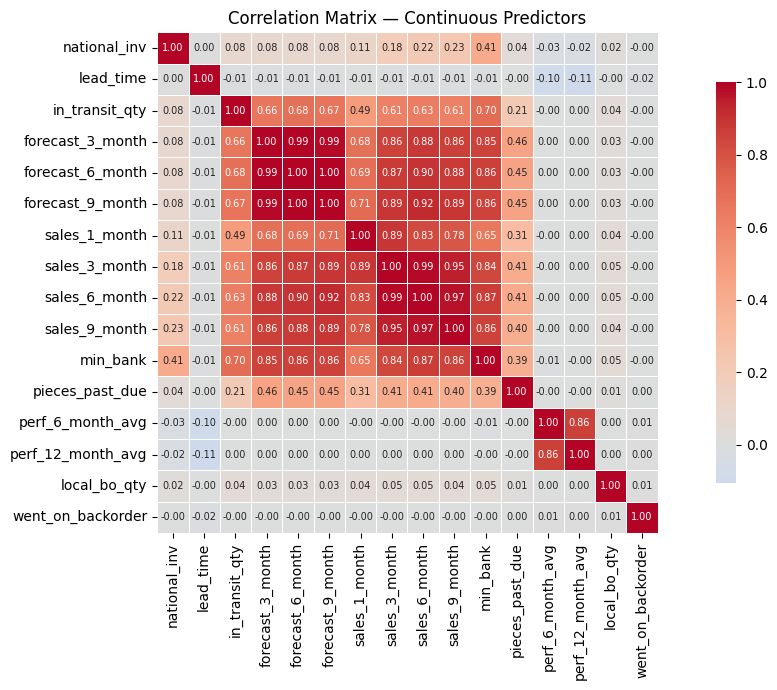

In [20]:
continuous_cols = ['national_inv', 'lead_time', 'in_transit_qty',
                   'forecast_3_month', 'forecast_6_month', 'forecast_9_month',
                   'sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month',
                   'min_bank', 'pieces_past_due', 'perf_6_month_avg',
                   'perf_12_month_avg', 'local_bo_qty']
fig, ax = plt.subplots(figsize=(12, 7))
corr = df_backorder_preprocessed[continuous_cols + ['went_on_backorder']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlation Matrix — Continuous Predictors')
plt.tight_layout()
plt.show()

In [21]:
# For reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### **Random Downsampling**

In [22]:
# performing random downsampling to deal with class imabalance - as implemented in paper

# Separate the two classes
df_yes = df_backorder_preprocessed[df_backorder_preprocessed['went_on_backorder'] == 1]
df_no  = df_backorder_preprocessed[df_backorder_preprocessed['went_on_backorder'] == 0]

print("\nBefore downsampling — Yes: ", len(df_yes)," No: ", len(df_no))

# Randomly sample 'No' rows to match 'Yes' count
df_no_downsampled = df_no.sample(n=len(df_yes), random_state=RANDOM_STATE)

# Combine and shuffle
df_balanced = pd.concat([df_yes, df_no_downsampled], axis=0)
df_balanced = df_balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("After downsampling, Yes: ", (df_balanced['went_on_backorder']==1).sum(),
      " No: ", (df_balanced['went_on_backorder']==0).sum())
print("Total rows: ",len(df_balanced))


Before downsampling — Yes:  8648  No:  975409
After downsampling, Yes:  8648  No:  8648
Total rows:  17296


### **Create 2 final Datasets**

In [23]:
""" Create Dataset 1 - 21 Features
    Create Dataset 2 - 5 features:
    national_inv, forecast_3_month, forecast_6_month, sales_9_month, perf_6_month_avg
    (selected based on feature importance rankings from prior literature)
    """
# Dataset 1: all 21 predictors + target
dataset_1_all21 = df_balanced.copy()

# Dataset 2: top 5 predictors + target
top_5_features = ['national_inv', 'lead_time', 'in_transit_qty',
                  'forecast_3_month', 'sales_3_month']
dataset_2_top5 = df_balanced[top_5_features + ['went_on_backorder']].copy()

print(f"Dataset 1 shape: {dataset_1_all21.shape}  (21 predictors + 1 target)")
print(f"Dataset 2 shape: {dataset_2_top5.shape}  (5 predictors + 1 target)")

Dataset 1 shape: (17296, 22)  (21 predictors + 1 target)
Dataset 2 shape: (17296, 6)  (5 predictors + 1 target)


### **Push Datasets to GitHub**

Add the new CSV files after downsampling to GitHub.

In [24]:

# # Configure Git identity
# !git config --global user.name "{GITHUB_USER}"
# !git config --global user.email "{GITHUB_USER}@example.com"

# # Clean up local repo folder if it exists
# if os.path.exists(GITHUB_REPO):
#     shutil.rmtree(GITHUB_REPO)

# # Clone using the authenticated URL
# repo_url = f"https://{token}@github.com/{GITHUB_USER}/{GITHUB_REPO}.git"
# !git clone {repo_url}

# # Ensure the 'Data' directory exists inside the repo
# repo_data_path = os.path.join(GITHUB_REPO, 'Data')

# # Save the datasets directly into the Data folder
# dataset_1_all21.to_csv(f'{repo_data_path}/dataset_1_all22.csv', index=False)
# dataset_2_top5.to_csv(f'{repo_data_path}/dataset_2_top5.csv', index=False)

# # Commit and Push
# %cd {GITHUB_REPO}
# !git add .
# !git commit -m "Add balanced datasets to Git"
# !git push origin main

# %cd /content
# print("\n Datasets added on GitHub.")


## **Model Implementation and Optimisation**

### **Load Preprocessed datasets**

In [25]:
# Load Preprocessed and downsampled Datasets for training
# Define the raw URLs for the datasets
base_url = "https://raw.githubusercontent.com/AswiniAnnieMathew/MXN441-Assignment2/main/Data/"
url_dataset_1 = f"{base_url}dataset_1_all22.csv"
url_dataset_2 = f"{base_url}dataset_2_top5.csv"

# Read the datasets into DataFrames
dataset_1_all21 = pd.read_csv(url_dataset_1)
dataset_2_top5 = pd.read_csv(url_dataset_2)

# Verification
print(f"Loaded Dataset 1 (All Features): {dataset_1_all21.shape}")
print(f"Loaded Dataset 2 (Top 5 Features): {dataset_2_top5.shape}")

display(dataset_1_all21.head())

Loaded Dataset 1 (All Features): (17296, 22)
Loaded Dataset 2 (Top 5 Features): (17296, 6)


,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,0,8.0,0,24,32,40,8,15,24,42,...,0,0.51,0.53,0,1,0,0,1,0,1
1,60,8.0,0,1000,2000,2000,115,303,590,1126,...,0,0.00,0.00,10,0,0,1,1,0,1
2,2,8.0,0,50,50,50,0,0,0,0,...,0,0.51,0.53,0,1,0,0,1,0,0
3,50,8.0,39,64,152,196,53,174,349,574,...,0,0.99,0.97,0,0,0,0,1,0,1
4,187,9.0,0,0,0,0,6,17,27,41,...,0,0.86,0.84,0,0,0,0,1,0,0


In [26]:
# set random seed
RANDOM_STATE = 42

### **Train/Test Split**

In [27]:
# 80/20 stratified split on dataset 1 with all 21 features
X_21 = dataset_1_all21.drop(columns=['went_on_backorder'])
y_21 = dataset_1_all21['went_on_backorder']

X_train_21, X_test_21, y_train_21, y_test_21 = train_test_split(
    X_21, y_21,
    test_size=0.2,
    stratify=y_21,
    random_state=RANDOM_STATE
)
print("\nAfter Stratified Train/Test Split on Dataset 1 with 21 Features")
print("Train:", X_train_21.shape, "positives:", y_train_21.sum())
print("Test: ", X_test_21.shape, "positives:", y_test_21.sum())

# 80/20 stratified split on dataset 2 with 5 features
X_5 = dataset_2_top5.drop(columns=['went_on_backorder'])
y_5 = dataset_2_top5['went_on_backorder']

X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(
    X_5, y_5,
    test_size=0.2,
    stratify=y_5,
    random_state=RANDOM_STATE
)
print("\nAfter Stratified Train/Test Split on Dataset 2 with 5 Features")
print("Train:", X_train_5.shape, "positives:", y_train_5.sum())
print("Test: ", X_test_5.shape, "positives:", y_test_5.sum())


After Stratified Train/Test Split on Dataset 1 with 21 Features
Train: (13836, 21) positives: 6918
Test:  (3460, 21) positives: 1730

After Stratified Train/Test Split on Dataset 2 with 5 Features
Train: (13836, 5) positives: 6918
Test:  (3460, 5) positives: 1730


### **Select Scaling Method**

In [28]:
# Compare Scaling on Default Models
results_scaling = []

# Applying Normalisation
scaler_norm = MinMaxScaler()
X_train_21_norm = scaler_norm.fit_transform(X_train_21)
X_test_21_norm  = scaler_norm.transform(X_test_21)

# LoR with normalisation
lor_norm = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lor_norm.fit(X_train_21_norm, y_train_21)
lor_norm_pred = lor_norm.predict(X_test_21_norm)
results_scaling.append({
    'scaling': 'normalisation', 'model': 'LoR',
    'test_acc': round(accuracy_score(y_test_21, lor_norm_pred), 4),
    'test_f1':  round(f1_score(y_test_21, lor_norm_pred, zero_division=0), 4)
})

# RF with normalisation
rf_norm = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rf_norm.fit(X_train_21_norm, y_train_21)
rf_norm_pred = rf_norm.predict(X_test_21_norm)
results_scaling.append({
    'scaling': 'normalisation', 'model': 'RF',
    'test_acc': round(accuracy_score(y_test_21, rf_norm_pred), 4),
    'test_f1':  round(f1_score(y_test_21, rf_norm_pred, zero_division=0), 4)
})

# XGB with normalisation
xgb_norm = xgb.XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss', verbosity=0)
xgb_norm.fit(X_train_21_norm, y_train_21)
xgb_norm_pred = xgb_norm.predict(X_test_21_norm)
results_scaling.append({
    'scaling': 'normalisation', 'model': 'XGB',
    'test_acc': round(accuracy_score(y_test_21, xgb_norm_pred), 4),
    'test_f1':  round(f1_score(y_test_21, xgb_norm_pred, zero_division=0), 4)
})

# Applying Standardisation
scaler_std = StandardScaler()
X_train_21_std = scaler_std.fit_transform(X_train_21)
X_test_21_std  = scaler_std.transform(X_test_21)

# LoR with standardisation
lor_std = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lor_std.fit(X_train_21_std, y_train_21)
lor_std_pred = lor_std.predict(X_test_21_std)
results_scaling.append({
    'scaling': 'standardisation', 'model': 'LoR',
    'test_acc': round(accuracy_score(y_test_21, lor_std_pred), 4),
    'test_f1':  round(f1_score(y_test_21, lor_std_pred, zero_division=0), 4)
})

# RF with standardisation
rf_std = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rf_std.fit(X_train_21_std, y_train_21)
rf_std_pred = rf_std.predict(X_test_21_std)
results_scaling.append({
    'scaling': 'standardisation', 'model': 'RF',
    'test_acc': round(accuracy_score(y_test_21, rf_std_pred), 4),
    'test_f1':  round(f1_score(y_test_21, rf_std_pred, zero_division=0), 4)
})

# XGB with standardisation
xgb_std = xgb.XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss', verbosity=0)
xgb_std.fit(X_train_21_std, y_train_21)
xgb_std_pred = xgb_std.predict(X_test_21_std)
results_scaling.append({
    'scaling': 'standardisation', 'model': 'XGB',
    'test_acc': round(accuracy_score(y_test_21, xgb_std_pred), 4),
    'test_f1':  round(f1_score(y_test_21, xgb_std_pred, zero_division=0), 4)
})

scaling_comparison_21 = pd.DataFrame(results_scaling)
print("Test accuracy by model and scaling:")
print(scaling_comparison_21.pivot(index='model', columns='scaling', values='test_acc'))

Test accuracy by model and scaling:
scaling  normalisation  standardisation
model                                  
LoR             0.5529           0.7058
RF              0.9110           0.9107
XGB             0.9035           0.9035


If we look at the accuracy and F1 score for both scaling methods, standardisation wins as it performs better across all the three models compared to normalistaion

### **Apply Selected Scaling Method**

In [29]:
final_scaler = StandardScaler()
# Applying scaling on dataset 1 with all 21 features
X_train_21_s = pd.DataFrame(
    final_scaler.fit_transform(X_train_21),
    columns=X_train_21.columns,
    index=X_train_21.index
)
X_test_21_s = pd.DataFrame(
    final_scaler.transform(X_test_21),
    columns=X_test_21.columns,
    index=X_test_21.index
)

# Applying scaling on dataset 2 with 5 features
X_train_5_s = pd.DataFrame(
    final_scaler.fit_transform(X_train_5),
    columns=X_train_5.columns,
    index=X_train_5.index
)
X_test_5_s = pd.DataFrame(
    final_scaler.transform(X_test_5),
    columns=X_test_5.columns,
    index=X_test_5.index
)
print("\nScaling applied to both datasets using:", final_scaler)
print("Dataset 1 train shape:", X_train_21_s.shape)
print("Dataset 2 train shape:", X_train_5_s.shape)


Scaling applied to both datasets using: StandardScaler()
Dataset 1 train shape: (13836, 21)
Dataset 2 train shape: (13836, 5)


### **Define hyperparameter ranges**

### **Commenting out all Model Implementation Codes Below. Running those codes will take time and hard to replicate when validating the notebook**

In [30]:
def get_hyperparameter_ranges(model_name):
    """
    This function is to define hyperparameter ranges from paper.
    deviations from the paper are documented with justification.
    """
    if model_name == 'LoR':
        # solver='liblinear' matches the paper (supports both L1 and L2 penalty)
        # max_iter=1000 gives sufficient iterations for convergence
        estimator = LogisticRegression(
            max_iter=1000,
            solver='liblinear',
            random_state=RANDOM_STATE
        )
        # DEVIATION FROM PAPER: C range narrowed from [0.001, 1000] to [0.1, 100]
        # Paper specifies C uniform over [0.001, 1000]
        # Preliminary runs showed very small C values (< 0.1) caused excessive
        # convergence time (~25 min for n_iter=10) under L1 penalty with
        # liblinear's coordinate-descent solver, without improving F1.
        # Range [0.1, 100] covers the practically relevant regularisation
        # strengths for standardised features and produced comparable F1
        # to the full range in pilot runs.
        param_dist = {
            'penalty': ['l1', 'l2'],
            'C': uniform(loc=0.1, scale=99.9)   # [0.1, 100]
        }

    elif model_name == 'RF':
        estimator = RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        # DEVIATION FROM PAPER: n_estimators upper bound reduced from 1200 to 500
        # Paper specifies n_estimators in [100, 1200]
        # Reducing upper bound to 500 gives comparable model capacity
        # on a 17K-row balanced dataset while reducing tuning time.
        # max_depth and min_samples_leaf match paper exactly.
        param_dist = {
            'n_estimators':     randint(100, 501),    # reduced from 1200 to 500
            'max_depth':        randint(3, 16),        # matches paper [3, 15]
            'min_samples_leaf': randint(1, 101)        # matches paper [1, 100]
        }

    elif model_name == 'XGB':
        # eval_metric='logloss': suppresses deprecation warning in XGBoost 2.0+
        # verbosity=0: silences per-iteration training output during search
        estimator = xgb.XGBClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            eval_metric='logloss',
            verbosity=0
        )
        # DEVIATION FROM PAPER: n_estimators upper bound reduced from 1200 to 500
        # reduces tuning time on small dataset
        # without meaningfully affecting model performance.
        # learning_rate range matches paper exactly [0.001, 1.0]
        param_dist = {
            'n_estimators':  randint(100, 501),        # reduced from 1200 to 500
            'max_depth':     randint(3, 16),            # matches paper [3, 15]
            'learning_rate': uniform(loc=0.001, scale=0.999)  # matches paper [0.001, 1.0]
        }
    return estimator, param_dist

In [31]:
N_ITER_SEARCH = 100   # paper uses 1000 but we reduced for Colab to 100
CV_FOLDS = 10         # matches paper

In [32]:
# 10-fold stratified cross-validation strategy
# Stratified ensures each fold preserves the class ratio
kfold = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

### **Tune LoR on Dataset 1**

In [33]:
# # Logistics Regression - Baseline on Dataset 1
# lor_estimator_21, lor_param_dist_21 = get_hyperparameter_ranges('LoR')
# lor_search_21 = RandomizedSearchCV(
#     estimator=lor_estimator_21,
#     param_distributions=lor_param_dist_21,
#     n_iter=N_ITER_SEARCH,
#     cv=kfold, scoring='f1', n_jobs=-1, random_state=RANDOM_STATE,
#     return_train_score=True, verbose=0
# )

# print("  Tuning LoR:", N_ITER_SEARCH, "iterations x", CV_FOLDS, "fold CV")
# t0 = time.time()
# lor_search_21.fit(X_train_21_s, y_train_21)
# lor_tune_time_21 = time.time() - t0

# lor_best_21 = lor_search_21.best_estimator_
# lor_cv_results_21 = lor_search_21.cv_results_

# # Clean up local repo folder if it exists
# if os.path.exists(GITHUB_REPO):
#     shutil.rmtree(GITHUB_REPO)

# # Clone and Save
# repo_url = f"https://{token}@github.com/{GITHUB_USER}/{GITHUB_REPO}.git"
# !git clone {repo_url}
# repo_models_path = os.path.join(GITHUB_REPO, 'Models')
# os.makedirs(repo_models_path, exist_ok=True)
# joblib.dump(lor_best_21, os.path.join(repo_models_path, 'lor_21features.pkl'))

# # Commit and Push
# %cd {GITHUB_REPO}
# !git add .
# !git commit -m "Add LoR 21 features model"
# !git push origin main
# %cd /content

### **Tune RF on Dataset 1**

In [34]:
# # Random Forest on Dataset 1
# rf_estimator_21, rf_param_dist_21 = get_hyperparameter_ranges('RF')
# rf_search_21 = RandomizedSearchCV(
#     estimator=rf_estimator_21,
#     param_distributions=rf_param_dist_21,
#     n_iter=N_ITER_SEARCH,
#     cv=kfold, scoring='f1', n_jobs=-1, random_state=RANDOM_STATE,
#     return_train_score=True, verbose=0
# )

# print("Tuning RF:", N_ITER_SEARCH, "iterations x", CV_FOLDS, "fold CV")
# t0 = time.time()
# rf_search_21.fit(X_train_21_s, y_train_21)
# rf_tune_time_21 = time.time() - t0

# rf_best_21 = rf_search_21.best_estimator_
# rf_cv_results_21 = rf_search_21.cv_results_

# # Clean up local repo folder if it exists
# if os.path.exists(GITHUB_REPO):
#     shutil.rmtree(GITHUB_REPO)

# # Clone and Save
# repo_url = f"https://{token}@github.com/{GITHUB_USER}/{GITHUB_REPO}.git"
# !git clone {repo_url}
# repo_models_path = os.path.join(GITHUB_REPO, 'Models')
# os.makedirs(repo_models_path, exist_ok=True)
# joblib.dump(rf_best_21, os.path.join(repo_models_path, 'rf_21features.pkl'))

# # Commit and Push
# %cd {GITHUB_REPO}
# !git add .
# !git commit -m "Add RF 21 features model"
# !git push origin main
# %cd /content

### **Tune XGB on Dataset 1**

In [35]:
# # XGBoost on Dataset 1
# xgb_estimator_21, xgb_param_dist_21 = get_hyperparameter_ranges('XGB')
# xgb_search_21 = RandomizedSearchCV(
#     estimator=xgb_estimator_21,
#     param_distributions=xgb_param_dist_21,
#     n_iter=N_ITER_SEARCH,
#     cv=kfold, scoring='f1', n_jobs=-1, random_state=RANDOM_STATE,
#     return_train_score=True, verbose=0
# )

# print("Tuning XGB:", N_ITER_SEARCH, "iterations x", CV_FOLDS, "fold CV")
# t0 = time.time()
# xgb_search_21.fit(X_train_21_s, y_train_21)
# xgb_tune_time_21 = time.time() - t0

# xgb_best_21 = xgb_search_21.best_estimator_
# xgb_cv_results_21 = xgb_search_21.cv_results_

# # Clean up local repo folder if it exists
# if os.path.exists(GITHUB_REPO):
#     shutil.rmtree(GITHUB_REPO)

# # Clone and Save
# repo_url = f"https://{token}@github.com/{GITHUB_USER}/{GITHUB_REPO}.git"
# !git clone {repo_url}
# repo_models_path = os.path.join(GITHUB_REPO, 'Models')
# os.makedirs(repo_models_path, exist_ok=True)
# joblib.dump(xgb_best_21, os.path.join(repo_models_path, 'xgb_21features.pkl'))

# # Commit and Push
# %cd {GITHUB_REPO}
# !git add .
# !git commit -m "Add XGB 21 features model"
# !git push origin main
# %cd /content

### **Tune LoR on Dataset 2**

In [36]:
# # logistics regression on Dataset 2
# lor_estimator_5, lor_param_dist_5 = get_hyperparameter_ranges('LoR')
# lor_search_5 = RandomizedSearchCV(
#     estimator=lor_estimator_5,
#     param_distributions=lor_param_dist_5,
#     n_iter=N_ITER_SEARCH,
#     cv=kfold, scoring='f1', n_jobs=-1, random_state=RANDOM_STATE,
#     return_train_score=True, verbose=0
# )

# print("Tuning LoR on Dataset 2", N_ITER_SEARCH, "iterations x", CV_FOLDS, "fold CV")
# t0 = time.time()
# lor_search_5.fit(X_train_5_s, y_train_5)
# lor_tune_time_5 = time.time() - t0

# lor_best_5 = lor_search_5.best_estimator_
# lor_cv_results_5 = lor_search_5.cv_results_

# # Clean up local repo folder if it exists
# if os.path.exists(GITHUB_REPO):
#     shutil.rmtree(GITHUB_REPO)

# # Clone and Save
# repo_url = f"https://{token}@github.com/{GITHUB_USER}/{GITHUB_REPO}.git"
# !git clone {repo_url}
# repo_models_path = os.path.join(GITHUB_REPO, 'Models')
# os.makedirs(repo_models_path, exist_ok=True)
# joblib.dump(lor_best_5, os.path.join(repo_models_path, 'lor_5features.pkl'))

# # Commit and Push
# %cd {GITHUB_REPO}
# !git add .
# !git commit -m "Add LoR 5 features model"
# !git push origin main
# %cd /content

### **Tune RF on Dataset 2**

In [37]:
# # RF on Dataset 2
# rf_estimator_5, rf_param_dist_5 = get_hyperparameter_ranges('RF')
# rf_search_5 = RandomizedSearchCV(
#     estimator=rf_estimator_5,
#     param_distributions=rf_param_dist_5,
#     n_iter=N_ITER_SEARCH,
#     cv=kfold, scoring='f1', n_jobs=-1, random_state=RANDOM_STATE,
#     return_train_score=True, verbose=0
# )

# print("Tuning RF on Dataset 2", N_ITER_SEARCH, "iterations x", CV_FOLDS, "fold CV")
# t0 = time.time()
# rf_search_5.fit(X_train_5_s, y_train_5)
# rf_tune_time_5 = time.time() - t0

# rf_best_5 = rf_search_5.best_estimator_

# # Clean up local repo folder if it exists
# if os.path.exists(GITHUB_REPO):
#     shutil.rmtree(GITHUB_REPO)

# # Clone and Save
# repo_url = f"https://{token}@github.com/{GITHUB_USER}/{GITHUB_REPO}.git"
# !git clone {repo_url}
# repo_models_path = os.path.join(GITHUB_REPO, 'Models')
# os.makedirs(repo_models_path, exist_ok=True)
# joblib.dump(rf_best_5, os.path.join(repo_models_path, 'rf_5features.pkl'))

# # Commit and Push
# %cd {GITHUB_REPO}
# !git add .
# !git commit -m "Add RF 5 features model"
# !git push origin main
# %cd /content

Tune XGB on Dataset 2

In [38]:
# # XGB — Dataset 2
# xgb_estimator_5, xgb_param_dist_5 = get_hyperparameter_ranges('XGB')
# xgb_search_5 = RandomizedSearchCV(
#     estimator=xgb_estimator_5,
#     param_distributions=xgb_param_dist_5,
#     n_iter=N_ITER_SEARCH,
#     cv=kfold, scoring='f1', n_jobs=-1, random_state=RANDOM_STATE,
#     return_train_score=True, verbose=0
# )

# print("Tuning XGB On Dataset 2", N_ITER_SEARCH, "iterations x", CV_FOLDS, "fold CV...")
# t0 = time.time()
# xgb_search_5.fit(X_train_5_s, y_train_5)
# xgb_tune_time_5 = time.time() - t0

# xgb_best_5 = xgb_search_5.best_estimator_

# # Clean up local repo folder if it exists
# if os.path.exists(GITHUB_REPO):
#     shutil.rmtree(GITHUB_REPO)

# # Clone and Save
# repo_url = f"https://{token}@github.com/{GITHUB_USER}/{GITHUB_REPO}.git"
# !git clone {repo_url}
# repo_models_path = os.path.join(GITHUB_REPO, 'Models')
# os.makedirs(repo_models_path, exist_ok=True)
# joblib.dump(xgb_best_5, os.path.join(repo_models_path, 'xgb_5features.pkl'))

# # Commit and Push
# %cd {GITHUB_REPO}
# !git add .
# !git commit -m "Add XGB 5 features model"
# !git push origin main
# %cd /content

### **Tuning Summary**

In [39]:

# print("Model   Scenario        CV F1    Tuning (min)")
# print("LoR     All 21 vars    ",
#       str(round(lor_search_21.best_score_, 4)), "   ",
#       str(round(lor_tune_time_21 / 60, 2)))
# print("RF      All 21 vars    ",
#       str(round(rf_search_21.best_score_, 4)), "   ",
#       str(round(rf_tune_time_21 / 60, 2)))
# print("XGB     All 21 vars    ",
#       str(round(xgb_search_21.best_score_, 4)), "   ",
#       str(round(xgb_tune_time_21 / 60, 2)))
# print("LoR     Only 5 vars    ",
#       str(round(lor_search_5.best_score_, 4)), "   ",
#       str(round(lor_tune_time_5 / 60, 2)))
# print("RF      Only 5 vars    ",
#       str(round(rf_search_5.best_score_, 4)), "   ",
#       str(round(rf_tune_time_5 / 60, 2)))
# print("XGB     Only 5 vars    ",
#       str(round(xgb_search_5.best_score_, 4)), "   ",
#       str(round(xgb_tune_time_5 / 60, 2)))

# # Save tuning times for Phase 3 evaluation table
# tuning_times = {
#     'LoR_21': lor_tune_time_21,
#     'RF_21':  rf_tune_time_21,
#     'XGB_21': xgb_tune_time_21,
#     'LoR_5':  lor_tune_time_5,
#     'RF_5':   rf_tune_time_5,
#     'XGB_5':  xgb_tune_time_5
# }

# print("Best models across 2 Datasets:")
# print("  21-feature: lor_best_21, rf_best_21, xgb_best_21")
# print("  5-feature:  lor_best_5,  rf_best_5,  xgb_best_5")

In [40]:
# ### Commenting out the whole section as we do not nedd to replace the deployed models
# # Save all models to Github
# # Configure Git identity

# !git config --global user.name "{GITHUB_USER}"
# !git config --global user.email "{GITHUB_USER}@example.com"

# # Clone using the authenticated URL
# repo_url = f"https://{token}@github.com/{GITHUB_USER}/{GITHUB_REPO}.git"
# !git clone {repo_url}


# # Ensure the Models directory exists inside the repo
# repo_models_path = os.path.join(GITHUB_REPO, 'Models')
# os.makedirs(repo_models_path, exist_ok=True)

# # models on Dataset 1

# # joblib.dump(lor_best_21,  os.path.join(repo_models_path, 'lor_21features.pkl'))
# # print("Saved: lor_21features.pkl")

# # joblib.dump(rf_best_21,   os.path.join(repo_models_path, 'rf_21features.pkl'))
# # print("Saved: rf_21features.pkl")

# # joblib.dump(xgb_best_21,  os.path.join(repo_models_path, 'xgb_21features.pkl'))
# # print("Saved: xgb_21features.pkl")

# # # models on Dataset 2

# # joblib.dump(lor_best_5,   os.path.join(repo_models_path, 'lor_5features.pkl'))
# # print("Saved: lor_5features.pkl")

# # joblib.dump(rf_best_5,    os.path.join(repo_models_path, 'rf_5features.pkl'))
# # print("Saved: rf_5features.pkl")

# # joblib.dump(xgb_best_5,   os.path.join(repo_models_path, 'xgb_5features.pkl'))
# # print("Saved: xgb_5features.pkl")

# # Save selected scaler
# joblib.dump(final_scaler, os.path.join(repo_models_path, 'scaler_21features.pkl'))
# print("Saved: scaler_21features.pkl")

# # Save tuning times
# joblib.dump(tuning_times, os.path.join(repo_models_path, 'tuning_times.pkl'))
# print("Saved: tuning_times.pkl")


# # Commit and Push
# %cd {GITHUB_REPO}
# !git add .
# !git commit -m "All models added to Git"
# !git push origin main

# %cd /content
# print("\n Models added on GitHub.")



## **Evaluation**

### **LoR Metrics - Dataset 1**

In [41]:
import urllib.request # Import for downloading files
import tempfile # Import for creating temporary files
import os

evaluation_results = [] # list to save all results

# LoR Metrics
model_file_name = 'lor_21features.pkl'
lor_model_repo_url = f"https://raw.githubusercontent.com/{GITHUB_USER}/{GITHUB_REPO}/main/Models/{model_file_name}"

# Define the filename for tuning_times
tuning_times_file_name = 'tuning_times.pkl'
tuning_times_repo_url = f"https://raw.githubusercontent.com/{GITHUB_USER}/{GITHUB_REPO}/main/Models/{tuning_times_file_name}"

# Load lor_best_21 model directly from URL
with urllib.request.urlopen(lor_model_repo_url) as response:
    lor_best_21 = joblib.load(response)

# Load tuning_times directly from URL
with urllib.request.urlopen(tuning_times_repo_url) as response:
    tuning_times = joblib.load(response)


# Train metrics
lor_train_pred_21      = lor_best_21.predict(X_train_21_s)
lor_train_acc_21       = round(accuracy_score(y_train_21, lor_train_pred_21), 4)
lor_train_recall_21    = round(recall_score(y_train_21, lor_train_pred_21, zero_division=0), 4)
lor_train_precision_21 = round(precision_score(y_train_21, lor_train_pred_21, zero_division=0), 4)
lor_train_f1_21        = round(f1_score(y_train_21, lor_train_pred_21, zero_division=0), 4)

# Test metrics
t0 = time.time()
lor_test_pred_21       = lor_best_21.predict(X_test_21_s)
lor_test_time_21       = round(time.time() - t0, 3)
lor_test_proba_21      = lor_best_21.predict_proba(X_test_21_s)[:, 1]
lor_test_acc_21        = round(accuracy_score(y_test_21, lor_test_pred_21), 4)
lor_test_recall_21     = round(recall_score(y_test_21, lor_test_pred_21, zero_division=0), 4)
lor_test_precision_21  = round(precision_score(y_test_21, lor_test_pred_21, zero_division=0), 4)
lor_test_f1_21         = round(f1_score(y_test_21, lor_test_pred_21, zero_division=0), 4)
lor_test_auc_21        = round(roc_auc_score(y_test_21, lor_test_proba_21), 4)

print("\nLoR — All 21 variables:")
print("  Train  Acc:", lor_train_acc_21, " Recall:", lor_train_recall_21,
      " Precision:", lor_train_precision_21, " F1:", lor_train_f1_21)
print("  Test   Acc:", lor_test_acc_21,  " Recall:", lor_test_recall_21,
      " Precision:", lor_test_precision_21,  " F1:", lor_test_f1_21,
      " AUC:", lor_test_auc_21)
print("  Tuning time:", str(round(tuning_times['LoR_21'] / 60, 2)), "min",
      " Test time:", lor_test_time_21, "sec")
print("  Confusion matrix:")
print(" ", confusion_matrix(y_test_21, lor_test_pred_21))

# append all metrics
evaluation_results.append({
    'Model':           'LoR',
    'Scenario':        'All 21 variables',
    'Train Accuracy':  lor_train_acc_21,
    'Train Recall':    lor_train_recall_21,
    'Train Precision': lor_train_precision_21,
    'Train F1':        lor_train_f1_21,
    'Test Accuracy':   lor_test_acc_21,
    'Test Recall':     lor_test_recall_21,
    'Test Precision':  lor_test_precision_21,
    'Test F1':         lor_test_f1_21,
    'Test ROC-AUC':    lor_test_auc_21,
    'Tuning (min)':    round(tuning_times['LoR_21'] / 60, 2),
    'Test (sec)':      lor_test_time_21
})

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



LoR — All 21 variables:
  Train  Acc: 0.7152  Recall: 0.8515  Precision: 0.6691  F1: 0.7494
  Test   Acc: 0.7153  Recall: 0.848  Precision: 0.6702  F1: 0.7487  AUC: 0.7888
  Tuning time: 4.25 min  Test time: 0.001 sec
  Confusion matrix:
  [[1008  722]
 [ 263 1467]]


### **RF Metrics - Dataset 1**

In [42]:
#  RF — Dataset 1
model_file_name = 'rf_21features.pkl'
lor_model_repo_url = f"https://raw.githubusercontent.com/{GITHUB_USER}/{GITHUB_REPO}/main/Models/{model_file_name}"

# Load lor_best_21 model directly from URL
with urllib.request.urlopen(lor_model_repo_url) as response:
    rf_best_21 = joblib.load(response)


rf_train_pred_21       = rf_best_21.predict(X_train_21_s)
rf_train_acc_21        = round(accuracy_score(y_train_21, rf_train_pred_21), 4)
rf_train_recall_21     = round(recall_score(y_train_21, rf_train_pred_21, zero_division=0), 4)
rf_train_precision_21  = round(precision_score(y_train_21, rf_train_pred_21, zero_division=0), 4)
rf_train_f1_21         = round(f1_score(y_train_21, rf_train_pred_21, zero_division=0), 4)

t0 = time.time()
rf_test_pred_21        = rf_best_21.predict(X_test_21_s)
rf_test_time_21        = round(time.time() - t0, 3)
rf_test_proba_21       = rf_best_21.predict_proba(X_test_21_s)[:, 1]
rf_test_acc_21         = round(accuracy_score(y_test_21, rf_test_pred_21), 4)
rf_test_recall_21      = round(recall_score(y_test_21, rf_test_pred_21, zero_division=0), 4)
rf_test_precision_21   = round(precision_score(y_test_21, rf_test_pred_21, zero_division=0), 4)
rf_test_f1_21          = round(f1_score(y_test_21, rf_test_pred_21, zero_division=0), 4)
rf_test_auc_21         = round(roc_auc_score(y_test_21, rf_test_proba_21), 4)

print("\nRF — All 21 variables:")
print("  Train  Acc:", rf_train_acc_21, " Recall:", rf_train_recall_21,
      " Precision:", rf_train_precision_21, " F1:", rf_train_f1_21)
print("  Test   Acc:", rf_test_acc_21,  " Recall:", rf_test_recall_21,
      " Precision:", rf_test_precision_21,  " F1:", rf_test_f1_21,
      " AUC:", rf_test_auc_21)
print("  Tuning time:", str(round(tuning_times['RF_21'] / 60, 2)), "min",
      " Test time:", rf_test_time_21, "sec")
print("  Confusion matrix:")
print(" ", confusion_matrix(y_test_21, rf_test_pred_21))

evaluation_results.append({
    'Model':           'RF',
    'Scenario':        'All 21 variables',
    'Train Accuracy':  rf_train_acc_21,
    'Train Recall':    rf_train_recall_21,
    'Train Precision': rf_train_precision_21,
    'Train F1':        rf_train_f1_21,
    'Test Accuracy':   rf_test_acc_21,
    'Test Recall':     rf_test_recall_21,
    'Test Precision':  rf_test_precision_21,
    'Test F1':         rf_test_f1_21,
    'Test ROC-AUC':    rf_test_auc_21,
    'Tuning (min)':    round(tuning_times['RF_21'] / 60, 2),
    'Test (sec)':      rf_test_time_21
})

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



RF — All 21 variables:
  Train  Acc: 0.9393  Recall: 0.9613  Precision: 0.9208  F1: 0.9406
  Test   Acc: 0.8971  Recall: 0.9277  Precision: 0.8742  F1: 0.9002  AUC: 0.9576
  Tuning time: 12.2 min  Test time: 0.125 sec
  Confusion matrix:
  [[1499  231]
 [ 125 1605]]


### **XGB Metrics - Dataset 1**

In [43]:
# XGB Metrics - Dataset 1
model_file_name = 'xgb_21features.pkl'
lor_model_repo_url = f"https://raw.githubusercontent.com/{GITHUB_USER}/{GITHUB_REPO}/main/Models/{model_file_name}"

# Load lor_best_21 model directly from URL
with urllib.request.urlopen(lor_model_repo_url) as response:
    xgb_best_21 = joblib.load(response)

xgb_train_pred_21      = xgb_best_21.predict(X_train_21_s)
xgb_train_acc_21       = round(accuracy_score(y_train_21, xgb_train_pred_21), 4)
xgb_train_recall_21    = round(recall_score(y_train_21, xgb_train_pred_21, zero_division=0), 4)
xgb_train_precision_21 = round(precision_score(y_train_21, xgb_train_pred_21, zero_division=0), 4)
xgb_train_f1_21        = round(f1_score(y_train_21, xgb_train_pred_21, zero_division=0), 4)

t0 = time.time()
xgb_test_pred_21       = xgb_best_21.predict(X_test_21_s)
xgb_test_time_21       = round(time.time() - t0, 3)
xgb_test_proba_21      = xgb_best_21.predict_proba(X_test_21_s)[:, 1]
xgb_test_acc_21        = round(accuracy_score(y_test_21, xgb_test_pred_21), 4)
xgb_test_recall_21     = round(recall_score(y_test_21, xgb_test_pred_21, zero_division=0), 4)
xgb_test_precision_21  = round(precision_score(y_test_21, xgb_test_pred_21, zero_division=0), 4)
xgb_test_f1_21         = round(f1_score(y_test_21, xgb_test_pred_21, zero_division=0), 4)
xgb_test_auc_21        = round(roc_auc_score(y_test_21, xgb_test_proba_21), 4)

print("\nXGB — All 21 variables:")
print("  Train  Acc:", xgb_train_acc_21, " Recall:", xgb_train_recall_21,
      " Precision:", xgb_train_precision_21, " F1:", xgb_train_f1_21)
print("  Test   Acc:", xgb_test_acc_21,  " Recall:", xgb_test_recall_21,
      " Precision:", xgb_test_precision_21,  " F1:", xgb_test_f1_21,
      " AUC:", xgb_test_auc_21)
print("  Tuning time:", str(round(tuning_times['XGB_21'] / 60, 2)), "min",
      " Test time:", xgb_test_time_21, "sec")
print("  Confusion matrix:")
print(" ", confusion_matrix(y_test_21, xgb_test_pred_21))

evaluation_results.append({
    'Model':           'XGB',
    'Scenario':        'All 21 variables',
    'Train Accuracy':  xgb_train_acc_21,
    'Train Recall':    xgb_train_recall_21,
    'Train Precision': xgb_train_precision_21,
    'Train F1':        xgb_train_f1_21,
    'Test Accuracy':   xgb_test_acc_21,
    'Test Recall':     xgb_test_recall_21,
    'Test Precision':  xgb_test_precision_21,
    'Test F1':         xgb_test_f1_21,
    'Test ROC-AUC':    xgb_test_auc_21,
    'Tuning (min)':    round(tuning_times['XGB_21'] / 60, 2),
    'Test (sec)':      xgb_test_time_21
})

/usr/lib/python3.12/pickle.py:1760: UserWarning: [03:13:08] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)



XGB — All 21 variables:
  Train  Acc: 0.998  Recall: 0.9983  Precision: 0.9977  F1: 0.998
  Test   Acc: 0.915  Recall: 0.9405  Precision: 0.8949  F1: 0.9171  AUC: 0.9632
  Tuning time: 4.37 min  Test time: 0.121 sec
  Confusion matrix:
  [[1539  191]
 [ 103 1627]]


In [44]:
# --- LoR — Dataset 2 ---
model_file_name = 'lor_5features.pkl'
lor_model_repo_url = f"https://raw.githubusercontent.com/{GITHUB_USER}/{GITHUB_REPO}/main/Models/{model_file_name}"

# Load lor_best_21 model directly from URL
with urllib.request.urlopen(lor_model_repo_url) as response:
    lor_best_5 = joblib.load(response)
lor_train_pred_5       = lor_best_5.predict(X_train_5_s)
lor_train_acc_5        = round(accuracy_score(y_train_5, lor_train_pred_5), 4)
lor_train_recall_5     = round(recall_score(y_train_5, lor_train_pred_5, zero_division=0), 4)
lor_train_precision_5  = round(precision_score(y_train_5, lor_train_pred_5, zero_division=0), 4)
lor_train_f1_5         = round(f1_score(y_train_5, lor_train_pred_5, zero_division=0), 4)

t0 = time.time()
lor_test_pred_5        = lor_best_5.predict(X_test_5_s)
lor_test_time_5        = round(time.time() - t0, 3)
lor_test_proba_5       = lor_best_5.predict_proba(X_test_5_s)[:, 1]
lor_test_acc_5         = round(accuracy_score(y_test_5, lor_test_pred_5), 4)
lor_test_recall_5      = round(recall_score(y_test_5, lor_test_pred_5, zero_division=0), 4)
lor_test_precision_5   = round(precision_score(y_test_5, lor_test_pred_5, zero_division=0), 4)
lor_test_f1_5          = round(f1_score(y_test_5, lor_test_pred_5, zero_division=0), 4)
lor_test_auc_5         = round(roc_auc_score(y_test_5, lor_test_proba_5), 4)

print("\nLoR — Only 5 variables:")
print("  Train  Acc:", lor_train_acc_5, " Recall:", lor_train_recall_5,
      " Precision:", lor_train_precision_5, " F1:", lor_train_f1_5)
print("  Test   Acc:", lor_test_acc_5,  " Recall:", lor_test_recall_5,
      " Precision:", lor_test_precision_5,  " F1:", lor_test_f1_5,
      " AUC:", lor_test_auc_5)
print("  Tuning time:", str(round(tuning_times['LoR_5'] / 60, 2)), "min",
      " Test time:", lor_test_time_5, "sec")
print("  Confusion matrix:")
print(" ", confusion_matrix(y_test_5, lor_test_pred_5))

evaluation_results.append({
    'Model':           'LoR',
    'Scenario':        'Only 5 variables',
    'Train Accuracy':  lor_train_acc_5,
    'Train Recall':    lor_train_recall_5,
    'Train Precision': lor_train_precision_5,
    'Train F1':        lor_train_f1_5,
    'Test Accuracy':   lor_test_acc_5,
    'Test Recall':     lor_test_recall_5,
    'Test Precision':  lor_test_precision_5,
    'Test F1':         lor_test_f1_5,
    'Test ROC-AUC':    lor_test_auc_5,
    'Tuning (min)':    round(tuning_times['LoR_5'] / 60, 2),
    'Test (sec)':      lor_test_time_5
})




LoR — Only 5 variables:
  Train  Acc: 0.7122  Recall: 0.8631  Precision: 0.663  F1: 0.7499
  Test   Acc: 0.7165  Recall: 0.874  Precision: 0.6646  F1: 0.7551  AUC: 0.7948
  Tuning time: 0.17 min  Test time: 0.002 sec
  Confusion matrix:
  [[ 967  763]
 [ 218 1512]]


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [45]:
# --- RF — Dataset 2 ---
model_file_name = 'rf_5features.pkl'
lor_model_repo_url = f"https://raw.githubusercontent.com/{GITHUB_USER}/{GITHUB_REPO}/main/Models/{model_file_name}"

# Load lor_best_21 model directly from URL
with urllib.request.urlopen(lor_model_repo_url) as response:
    rf_best_5 = joblib.load(response)
rf_train_pred_5        = rf_best_5.predict(X_train_5_s)
rf_train_acc_5         = round(accuracy_score(y_train_5, rf_train_pred_5), 4)
rf_train_recall_5      = round(recall_score(y_train_5, rf_train_pred_5, zero_division=0), 4)
rf_train_precision_5   = round(precision_score(y_train_5, rf_train_pred_5, zero_division=0), 4)
rf_train_f1_5          = round(f1_score(y_train_5, rf_train_pred_5, zero_division=0), 4)

t0 = time.time()
rf_test_pred_5         = rf_best_5.predict(X_test_5_s)
rf_test_time_5         = round(time.time() - t0, 3)
rf_test_proba_5        = rf_best_5.predict_proba(X_test_5_s)[:, 1]
rf_test_acc_5          = round(accuracy_score(y_test_5, rf_test_pred_5), 4)
rf_test_recall_5       = round(recall_score(y_test_5, rf_test_pred_5, zero_division=0), 4)
rf_test_precision_5    = round(precision_score(y_test_5, rf_test_pred_5, zero_division=0), 4)
rf_test_f1_5           = round(f1_score(y_test_5, rf_test_pred_5, zero_division=0), 4)
rf_test_auc_5          = round(roc_auc_score(y_test_5, rf_test_proba_5), 4)

print("\nRF — Only 5 variables:")
print("  Train  Acc:", rf_train_acc_5, " Recall:", rf_train_recall_5,
      " Precision:", rf_train_precision_5, " F1:", rf_train_f1_5)
print("  Test   Acc:", rf_test_acc_5,  " Recall:", rf_test_recall_5,
      " Precision:", rf_test_precision_5,  " F1:", rf_test_f1_5,
      " AUC:", rf_test_auc_5)
print("  Tuning time:", str(round(tuning_times['RF_5'] / 60, 2)), "min",
      " Test time:", rf_test_time_5, "sec")
print("  Confusion matrix:")
print(" ", confusion_matrix(y_test_5, rf_test_pred_5))

evaluation_results.append({
    'Model':           'RF',
    'Scenario':        'Only 5 variables',
    'Train Accuracy':  rf_train_acc_5,
    'Train Recall':    rf_train_recall_5,
    'Train Precision': rf_train_precision_5,
    'Train F1':        rf_train_f1_5,
    'Test Accuracy':   rf_test_acc_5,
    'Test Recall':     rf_test_recall_5,
    'Test Precision':  rf_test_precision_5,
    'Test F1':         rf_test_f1_5,
    'Test ROC-AUC':    rf_test_auc_5,
    'Tuning (min)':    round(tuning_times['RF_5'] / 60, 2),
    'Test (sec)':      rf_test_time_5
})



/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



RF — Only 5 variables:
  Train  Acc: 0.9  Recall: 0.9104  Precision: 0.8918  F1: 0.901
  Test   Acc: 0.8786  Recall: 0.8971  Precision: 0.8651  F1: 0.8808  AUC: 0.9478
  Tuning time: 10.55 min  Test time: 0.226 sec
  Confusion matrix:
  [[1488  242]
 [ 178 1552]]


In [46]:
# --- XGB — Dataset 2 ---
model_file_name = 'xgb_5features.pkl'
lor_model_repo_url = f"https://raw.githubusercontent.com/{GITHUB_USER}/{GITHUB_REPO}/main/Models/{model_file_name}"

# Load lor_best_21 model directly from URL
with urllib.request.urlopen(lor_model_repo_url) as response:
    xgb_best_5 = joblib.load(response)
xgb_train_pred_5       = xgb_best_5.predict(X_train_5_s)
xgb_train_acc_5        = round(accuracy_score(y_train_5, xgb_train_pred_5), 4)
xgb_train_recall_5     = round(recall_score(y_train_5, xgb_train_pred_5, zero_division=0), 4)
xgb_train_precision_5  = round(precision_score(y_train_5, xgb_train_pred_5, zero_division=0), 4)
xgb_train_f1_5         = round(f1_score(y_train_5, xgb_train_pred_5, zero_division=0), 4)

t0 = time.time()
xgb_test_pred_5        = xgb_best_5.predict(X_test_5_s)
xgb_test_time_5        = round(time.time() - t0, 3)
xgb_test_proba_5       = xgb_best_5.predict_proba(X_test_5_s)[:, 1]
xgb_test_acc_5         = round(accuracy_score(y_test_5, xgb_test_pred_5), 4)
xgb_test_recall_5      = round(recall_score(y_test_5, xgb_test_pred_5, zero_division=0), 4)
xgb_test_precision_5   = round(precision_score(y_test_5, xgb_test_pred_5, zero_division=0), 4)
xgb_test_f1_5          = round(f1_score(y_test_5, xgb_test_pred_5, zero_division=0), 4)
xgb_test_auc_5         = round(roc_auc_score(y_test_5, xgb_test_proba_5), 4)

print("\nXGB — Only 5 variables:")
print("  Train  Acc:", xgb_train_acc_5, " Recall:", xgb_train_recall_5,
      " Precision:", xgb_train_precision_5, " F1:", xgb_train_f1_5)
print("  Test   Acc:", xgb_test_acc_5,  " Recall:", xgb_test_recall_5,
      " Precision:", xgb_test_precision_5,  " F1:", xgb_test_f1_5,
      " AUC:", xgb_test_auc_5)
print("  Tuning time:", str(round(tuning_times['XGB_5'] / 60, 2)), "min",
      " Test time:", xgb_test_time_5, "sec")
print("  Confusion matrix:")
print(" ", confusion_matrix(y_test_5, xgb_test_pred_5))

evaluation_results.append({
    'Model':           'XGB',
    'Scenario':        'Only 5 variables',
    'Train Accuracy':  xgb_train_acc_5,
    'Train Recall':    xgb_train_recall_5,
    'Train Precision': xgb_train_precision_5,
    'Train F1':        xgb_train_f1_5,
    'Test Accuracy':   xgb_test_acc_5,
    'Test Recall':     xgb_test_recall_5,
    'Test Precision':  xgb_test_precision_5,
    'Test F1':         xgb_test_f1_5,
    'Test ROC-AUC':    xgb_test_auc_5,
    'Tuning (min)':    round(tuning_times['XGB_5'] / 60, 2),
    'Test (sec)':      xgb_test_time_5
})



XGB — Only 5 variables:
  Train  Acc: 0.9247  Recall: 0.9337  Precision: 0.9172  F1: 0.9254
  Test   Acc: 0.8798  Recall: 0.8971  Precision: 0.867  F1: 0.8818  AUC: 0.9445
  Tuning time: 2.09 min  Test time: 0.023 sec
  Confusion matrix:
  [[1492  238]
 [ 178 1552]]


In [47]:
# FINAL RESULTS TABLE — matching paper format

evaluation_df = pd.DataFrame(evaluation_results)

print("FINAL RESULTS TABLE")
print(evaluation_df.to_string(index=False))



FINAL RESULTS TABLE
Model         Scenario  Train Accuracy  Train Recall  Train Precision  Train F1  Test Accuracy  Test Recall  Test Precision  Test F1  Test ROC-AUC  Tuning (min)  Test (sec)
  LoR All 21 variables          0.7152        0.8515           0.6691    0.7494         0.7153       0.8480          0.6702   0.7487        0.7888          4.25       0.001
   RF All 21 variables          0.9393        0.9613           0.9208    0.9406         0.8971       0.9277          0.8742   0.9002        0.9576         12.20       0.125
  XGB All 21 variables          0.9980        0.9983           0.9977    0.9980         0.9150       0.9405          0.8949   0.9171        0.9632          4.37       0.121
  LoR Only 5 variables          0.7122        0.8631           0.6630    0.7499         0.7165       0.8740          0.6646   0.7551        0.7948          0.17       0.002
   RF Only 5 variables          0.9000        0.9104           0.8918    0.9010         0.8786       0.8971        

All 21: [4.25, 12.2, 4.37]
Top 5:  [0.17, 10.55, 2.09]


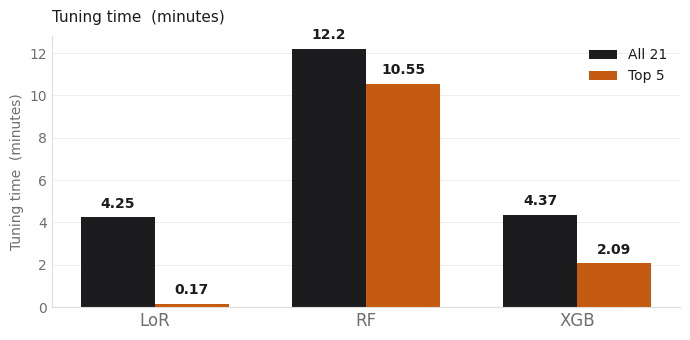

Saved: tuning_time_comparison.png


In [48]:

models = ['LoR', 'RF', 'XGB']

times_21 = [
    float(evaluation_df[(evaluation_df['Model'] == 'LoR') &
          (evaluation_df['Scenario'].str.contains('21'))]['Tuning (min)'].values[0]),
    float(evaluation_df[(evaluation_df['Model'] == 'RF') &
          (evaluation_df['Scenario'].str.contains('21'))]['Tuning (min)'].values[0]),
    float(evaluation_df[(evaluation_df['Model'] == 'XGB') &
          (evaluation_df['Scenario'].str.contains('21'))]['Tuning (min)'].values[0]),
]

times_5 = [
    float(evaluation_df[(evaluation_df['Model'] == 'LoR') &
          (evaluation_df['Scenario'].str.contains('5'))]['Tuning (min)'].values[0]),
    float(evaluation_df[(evaluation_df['Model'] == 'RF') &
          (evaluation_df['Scenario'].str.contains('5'))]['Tuning (min)'].values[0]),
    float(evaluation_df[(evaluation_df['Model'] == 'XGB') &
          (evaluation_df['Scenario'].str.contains('5'))]['Tuning (min)'].values[0]),
]

print("All 21:", times_21)
print("Top 5: ", times_5)

# Chart setup
x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 3.5))
# fig.patch.set_facecolor('#F5F5F7')
# ax.set_facecolor('#F5F5F7')

# Bars
bars1 = ax.bar(x - width/2, times_21, width,
               color='#1C1C1E', label='All 21')
bars2 = ax.bar(x + width/2, times_5,  width,
               color='#C55A11', label='Top 5')

# Value labels on top of each bar
for bar in bars1:
    h = round(bar.get_height(), 2)
    ax.text(bar.get_x() + bar.get_width() / 2,
            h + 0.3, str(h),
            ha='center', va='bottom',
            fontsize=10, color='#1C1C1E', fontweight='bold')

for bar in bars2:
    h = round(bar.get_height(), 2)
    ax.text(bar.get_x() + bar.get_width() / 2,
            h + 0.3, str(h),
            ha='center', va='bottom',
            fontsize=10, color='#1C1C1E', fontweight='bold')

# Styling
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12, color='#1C1C1E')
ax.set_ylabel('Tuning time  (minutes)', fontsize=10, color='#6E6E73')
ax.set_title('Tuning time  (minutes)', fontsize=11,
             color='#1C1C1E', loc='left', pad=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#DDDDDD')
ax.spines['bottom'].set_color('#DDDDDD')
ax.tick_params(colors='#6E6E73', length=0)
ax.yaxis.grid(True, color='#EEEEEE', linewidth=0.8)
ax.set_axisbelow(True)

ax.legend(loc='upper right', fontsize=10,
          frameon=False, labelcolor='#1C1C1E')

plt.tight_layout()
plt.savefig('tuning_time_comparison.png',
            dpi=150, bbox_inches='tight',
            facecolor='#F5F5F7')
plt.show()
print("Saved: tuning_time_comparison.png")

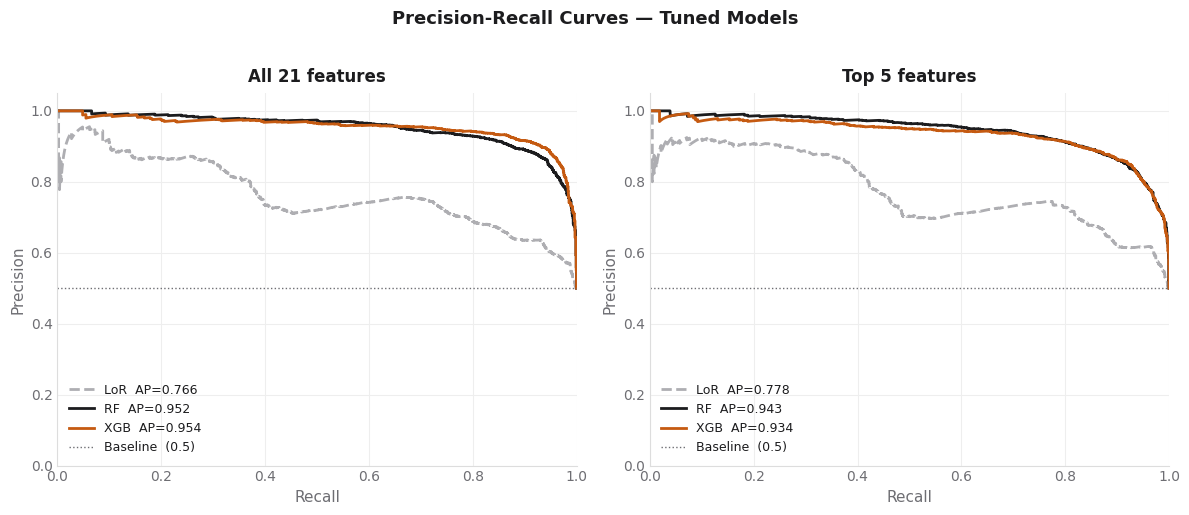

Saved: precision_recall_curves.png


In [49]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# PRECISION-RECALL CURVES

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {
    'LoR': '#AEAEB2',
    'RF':  '#1C1C1E',
    'XGB': '#C55A11',
}
linestyles = {
    'LoR': '--',
    'RF':  '-',
    'XGB': '-',
}

# Dataset 1 — All 21 features
ax1 = axes[0]

for model_name, model, X_te, y_te in [
    ('LoR', lor_best_21, X_test_21_s, y_test_21),
    ('RF',  rf_best_21,  X_test_21_s, y_test_21),
    ('XGB', xgb_best_21, X_test_21_s, y_test_21),
]:
    y_proba = model.predict_proba(X_te)[:, 1]
    precision, recall, _ = precision_recall_curve(y_te, y_proba)
    ap = average_precision_score(y_te, y_proba)

    ax1.plot(recall, precision,
             color=colors[model_name],
             linestyle=linestyles[model_name],
             linewidth=2,
             label=model_name + "  AP=" + str(round(ap, 3)))

# Baseline — random classifier
baseline = y_test_21.mean()
ax1.axhline(y=baseline, linestyle=':', color='#6E6E73', linewidth=1,
            label="Baseline  (" + str(round(baseline, 3)) + ")")

ax1.set_xlabel('Recall', fontsize=11, color='#6E6E73')
ax1.set_ylabel('Precision', fontsize=11, color='#6E6E73')
ax1.set_title('All 21 features', fontsize=12,
              color='#1C1C1E', fontweight='bold', pad=8)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=9, frameon=False, labelcolor='#1C1C1E')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#DDDDDD')
ax1.spines['bottom'].set_color('#DDDDDD')
ax1.tick_params(colors='#6E6E73', length=0)
ax1.yaxis.grid(True, color='#EEEEEE', linewidth=0.8)
ax1.xaxis.grid(True, color='#EEEEEE', linewidth=0.8)
ax1.set_axisbelow(True)

# Dataset 2 — Top 5 features
ax2 = axes[1]

for model_name, model, X_te, y_te in [
    ('LoR', lor_best_5, X_test_5_s, y_test_5),
    ('RF',  rf_best_5,  X_test_5_s, y_test_5),
    ('XGB', xgb_best_5, X_test_5_s, y_test_5),
]:
    y_proba = model.predict_proba(X_te)[:, 1]
    precision, recall, _ = precision_recall_curve(y_te, y_proba)
    ap = average_precision_score(y_te, y_proba)

    ax2.plot(recall, precision,
             color=colors[model_name],
             linestyle=linestyles[model_name],
             linewidth=2,
             label=model_name + "  AP=" + str(round(ap, 3)))

baseline = y_test_5.mean()
ax2.axhline(y=baseline, linestyle=':', color='#6E6E73', linewidth=1,
            label="Baseline  (" + str(round(baseline, 3)) + ")")

ax2.set_xlabel('Recall', fontsize=11, color='#6E6E73')
ax2.set_ylabel('Precision', fontsize=11, color='#6E6E73')
ax2.set_title('Top 5 features', fontsize=12,
              color='#1C1C1E', fontweight='bold', pad=8)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=9, frameon=False, labelcolor='#1C1C1E')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#DDDDDD')
ax2.spines['bottom'].set_color('#DDDDDD')
ax2.tick_params(colors='#6E6E73', length=0)
ax2.yaxis.grid(True, color='#EEEEEE', linewidth=0.8)
ax2.xaxis.grid(True, color='#EEEEEE', linewidth=0.8)
ax2.set_axisbelow(True)

# Overall title
fig.suptitle('Precision-Recall Curves — Tuned Models',
             fontsize=13, color='#1C1C1E',
             fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('precision_recall_curves.png',
            dpi=150, bbox_inches='tight',
            facecolor='#F5F5F7')
plt.show()
print("Saved: precision_recall_curves.png")

## **Extensions**

In [51]:
# ============================================================
# EXTENSION: Additional imports
# ============================================================

from sklearn.inspection import permutation_importance
from sklearn.metrics import precision_recall_curve, average_precision_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import shap
import warnings
warnings.filterwarnings('ignore')

# !pip install imbalanced-learn shap

### **Extension 1: Data-driven Feature Importance vs Paper's Selection (Correction of Paper - Doesn't contribute so not included)**

EXTENSION 1: FEATURE IMPORTANCE COMPARISON

Computing RF permutation importance...
Computing XGB permutation importance...

Feature importance summary (sorted by average rank across all methods):
          feature  RF_Gini  RF_Permutation  XGB_Gain  XGB_Permutation  avg_rank
     national_inv   0.2361          0.2439    0.1051           0.3016      1.50
 forecast_3_month   0.1410          0.0159    0.2079           0.0176      4.00
    sales_1_month   0.0413          0.0149    0.0664           0.0400      5.00
   in_transit_qty   0.0418          0.0164    0.0447           0.0198      5.50
    sales_3_month   0.0422          0.0107    0.0316           0.0151      7.00
        lead_time   0.0244          0.0170    0.0300           0.0246      7.25
 forecast_6_month   0.1521          0.0106    0.0309           0.0106      7.75
    sales_9_month   0.0404          0.0089    0.0244           0.0430      8.00
 forecast_9_month   0.1060          0.0071    0.0273           0.0131     10.00
    

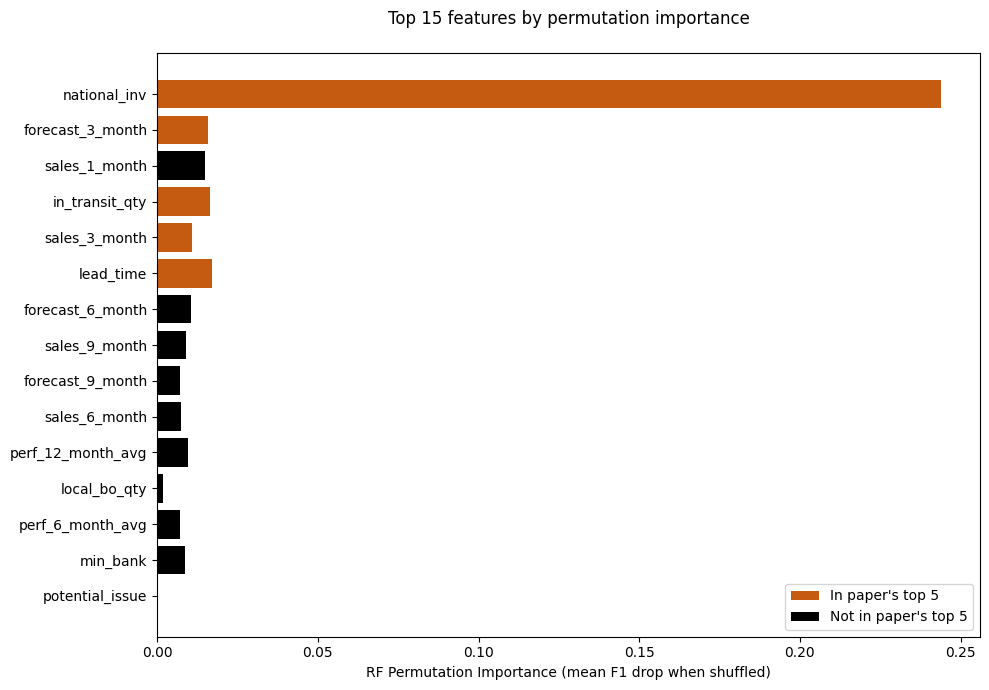


Extension 1 complete. Outputs saved.


In [58]:
# ============================================================
# EXTENSION 1: Data-driven feature importance
# vs paper's literature-derived top 5
# ============================================================
# The paper selects 5 features from prior literature without
# verifying whether these are the most important features in
# this specific dataset. We compute importance from the data
# and compare against the paper's selection.
# ============================================================

print("=" * 60)
print("EXTENSION 1: FEATURE IMPORTANCE COMPARISON")
print("=" * 60)

# Paper's 5 features selected from prior literature (Table 2)
PAPER_TOP5 = ['national_inv', 'lead_time', 'in_transit_qty',
                  'forecast_3_month', 'sales_3_month']

feature_names = X_train_21_s.columns.tolist()

# Retrieve tuned models from Phase 3
rf_model  = rf_best_21
xgb_model = xgb_best_21

# ----- Step 1: Native feature importance -----

rf_native = pd.DataFrame({
    'feature':    feature_names,
    'RF_Gini':    rf_model.feature_importances_
})

xgb_native = pd.DataFrame({
    'feature':   feature_names,
    'XGB_Gain':  xgb_model.feature_importances_
})

# ----- Step 2: Permutation importance -----
# More reliable than Gini for correlated features
# (sales and forecast variables are highly correlated in this dataset)

print("\nComputing RF permutation importance...")
rf_perm_result = permutation_importance(
    rf_model, X_test_21_s, y_test_21,
    n_repeats=10, scoring='f1',
    random_state=RANDOM_STATE, n_jobs=-1
)

print("Computing XGB permutation importance...")
xgb_perm_result = permutation_importance(
    xgb_model, X_test_21_s, y_test_21,
    n_repeats=10, scoring='f1',
    random_state=RANDOM_STATE, n_jobs=-1
)

rf_native['RF_Permutation']  = rf_perm_result.importances_mean
xgb_native['XGB_Permutation'] = xgb_perm_result.importances_mean

# ----- Step 3: Combine and rank -----

importance_df = rf_native.merge(xgb_native, on='feature')

# Rank each feature per method (rank 1 = most important)
for col in ['RF_Gini', 'RF_Permutation', 'XGB_Gain', 'XGB_Permutation']:
    importance_df[col + '_rank'] = importance_df[col].rank(
        ascending=False, method='min'
    ).astype(int)

rank_cols = [c for c in importance_df.columns if c.endswith('_rank')]
importance_df['avg_rank'] = importance_df[rank_cols].mean(axis=1)
importance_df = importance_df.sort_values('avg_rank').reset_index(drop=True)

print("\nFeature importance summary (sorted by average rank across all methods):")
display_cols = ['feature', 'RF_Gini', 'RF_Permutation',
                'XGB_Gain', 'XGB_Permutation', 'avg_rank']
print(importance_df[display_cols].round(4).to_string(index=False))

# ----- Step 4: Your top 5 vs paper's top 5 -----

your_top5      = importance_df['feature'].head(5).tolist()
overlap        = sorted(set(your_top5) & set(PAPER_TOP5))
yours_only     = sorted(set(your_top5) - set(PAPER_TOP5))
paper_only     = sorted(set(PAPER_TOP5) - set(your_top5))

print(f"\nPaper's top 5 (from literature): {PAPER_TOP5}")
print(f"Your top 5 (from data):          {your_top5}")
print(f"Overlap ({len(overlap)}/5):      {overlap}")
print(f"Only in your top 5:              {yours_only}")
print(f"Only in paper's top 5:           {paper_only}")

# ----- Step 5: Train RF on YOUR top 5 and compare to paper's top 5 -----
# This is the empirical test — does data-driven selection perform better?

from sklearn.preprocessing import StandardScaler

def quick_evaluate(X_tr, X_te, y_tr, y_te, label):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    model = RandomForestClassifier(
        **{k: v for k, v in rf_model.get_params().items()}
    )
    model.fit(X_tr_s, y_tr)
    y_pred = model.predict(X_te_s)
    print(f"  {label}: Acc={accuracy_score(y_te, y_pred):.4f}  "
          f"F1={f1_score(y_te, y_pred, zero_division=0):.4f}  "
          f"Recall={recall_score(y_te, y_pred, zero_division=0):.4f}")
    return {
        'Feature set': label,
        'Test Accuracy': round(accuracy_score(y_te, y_pred), 4),
        'Test F1':       round(f1_score(y_te, y_pred, zero_division=0), 4),
        'Test Recall':   round(recall_score(y_te, y_pred, zero_division=0), 4),
        'Test Precision':round(precision_score(y_te, y_pred, zero_division=0), 4)
    }

# Get raw (unscaled) splits for the feature subsets
X_full = dataset_1_all21.drop(columns=['went_on_backorder'])
y_full = dataset_1_all21['went_on_backorder']
X_tr_raw, X_te_raw, y_tr_raw, y_te_raw = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=RANDOM_STATE
)

print("\nRF performance comparison across feature sets:")
results_feat = []
results_feat.append(quick_evaluate(
    X_tr_raw[PAPER_TOP5], X_te_raw[PAPER_TOP5], y_tr_raw, y_te_raw,
    "Paper's top 5 (literature)"
))
results_feat.append(quick_evaluate(
    X_tr_raw[your_top5], X_te_raw[your_top5], y_tr_raw, y_te_raw,
    "Your top 5 (data-driven)"
))
results_feat.append(quick_evaluate(
    X_tr_raw, X_te_raw, y_tr_raw, y_te_raw,
    "All 22 features"
))

feat_comparison_df = pd.DataFrame(results_feat)
print("\nSummary:")
print(feat_comparison_df.to_string(index=False))

# ----- Step 6: Visualisation -----

fig, ax = plt.subplots(figsize=(10, 7))
top15 = importance_df.head(15).copy()
colors = ['#C55A11' if f in PAPER_TOP5 else 'black'
          for f in top15['feature']]

ax.barh(top15['feature'], top15['RF_Permutation'], color=colors)
ax.set_xlabel('RF Permutation Importance (mean F1 drop when shuffled)')
ax.set_title('Top 15 features by permutation importance\n')
ax.invert_yaxis()

# Add legend manually
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#C55A11', label="In paper's top 5"),
                   Patch(facecolor='black', label="Not in paper's top 5")]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('ext1_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

importance_df.to_csv('ext1_feature_importance.csv', index=False)
feat_comparison_df.to_csv('ext1_feature_set_comparison.csv', index=False)
print("\nExtension 1 complete. Outputs saved.")

### **Extension 2: SMOTE vs Random Downsampling**

EXTENSION 2: SMOTE VS RANDOM DOWNSAMPLING
Full training set: 787,245 rows, 6,918 positives (0.88%)
Test set (imbalanced - deployment realistic): 196,812 rows, 1,730 positives (0.88%)

After random downsampling: 13,836 rows, 6,918 positives (50.00%)
After SMOTE:               1,560,654 rows, 780,327 positives (50.00%)

XGB results evaluated on IMBALANCED test set:

  Random downsampling (paper):
    Accuracy=0.8862  Recall=0.9410  Precision=0.0681  F1=0.1269  AUC=0.9620
    Confusion matrix:
    [[172790  22292]
 [   102   1628]]

  SMOTE:
    Accuracy=0.9924  Recall=0.4896  Precision=0.5821  F1=0.5319  AUC=0.9725
    Confusion matrix:
    [[194474    608]
 [   883    847]]

Comparison summary:
        Resampling strategy  Training rows  Test Accuracy  Test Recall  Test Precision  Test F1  Test ROC-AUC  Train time (sec)
Random downsampling (paper)          13836         0.8862       0.9410          0.0681   0.1269        0.9620              3.31
                      SMOTE        156065

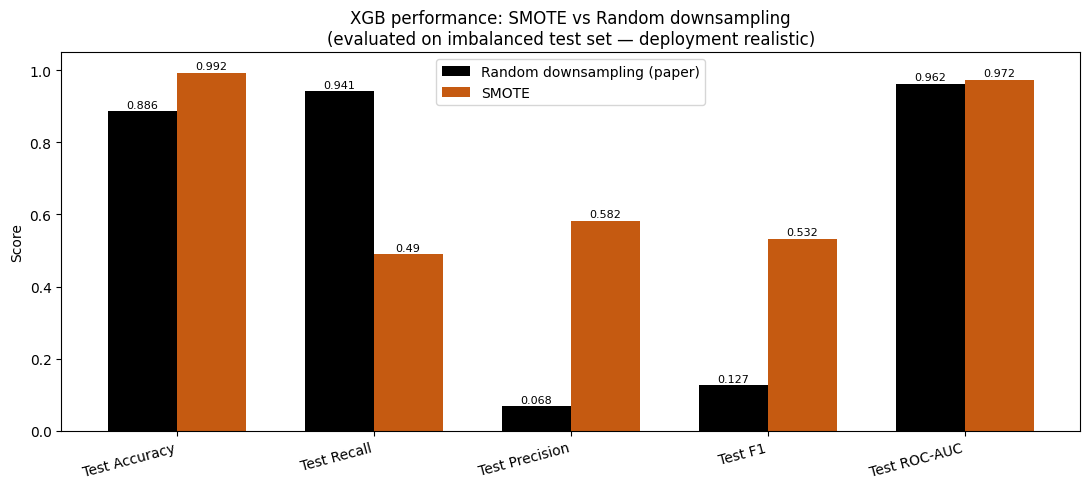


Extension 2 complete. Outputs saved.


In [53]:
# ============================================================
# EXTENSION 2: SMOTE vs random downsampling
# ============================================================
# The paper uses random downsampling to address class imbalance,
# which discards ~99% of majority class data (~1M rows kept to
# only ~8,900). SMOTE (Synthetic Minority Over-sampling TEchnique)
# synthesises new minority examples instead of discarding majority
# data, preserving more information for training.
# We compare both strategies using XGB with the same tuned
# hyperparameters, evaluated on the imbalanced test set to
# reflect deployment conditions.
# ============================================================

print("=" * 60)
print("EXTENSION 2: SMOTE VS RANDOM DOWNSAMPLING")
print("=" * 60)

# ----- Setup: use FULL preprocessed data (before downsampling) -----
# Recreate from df_backorder_raw — encode but do NOT downsample

df_ext2 = df_backorder_raw.copy()

# Drop SKU
df_ext2 = df_ext2.drop(columns=['sku'])

# Drop rows with missing lead_time (matches paper)
df_ext2 = df_ext2.dropna(subset=['lead_time'])

# Encode binary flags
binary_cols = ['potential_issue', 'deck_risk', 'oe_constraint',
               'ppap_risk', 'stop_auto_buy', 'rev_stop']
for col in binary_cols:
    df_ext2[col] = (df_ext2[col] == 'Yes').astype(int)

# Encode target
df_ext2['went_on_backorder'] = (df_ext2['went_on_backorder'] == 'Yes').astype(int)

X_ext2 = df_ext2.drop(columns=['went_on_backorder'])
y_ext2 = df_ext2['went_on_backorder']

# 80/20 stratified split on FULL imbalanced data
X_tr_e2, X_te_e2, y_tr_e2, y_te_e2 = train_test_split(
    X_ext2, y_ext2,
    test_size=0.2, stratify=y_ext2, random_state=RANDOM_STATE
)

# Standardise (fit on train only)
scaler_e2 = StandardScaler()
X_tr_e2_s = scaler_e2.fit_transform(X_tr_e2)
X_te_e2_s = scaler_e2.transform(X_te_e2)

print(f"Full training set: {len(y_tr_e2):,} rows, "
      f"{y_tr_e2.sum():,} positives ({y_tr_e2.mean()*100:.2f}%)")
print(f"Test set (imbalanced - deployment realistic): "
      f"{len(y_te_e2):,} rows, "
      f"{y_te_e2.sum():,} positives ({y_te_e2.mean()*100:.2f}%)")

# ----- Strategy A: Random downsampling (paper's approach) -----

rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_tr_rus, y_tr_rus = rus.fit_resample(X_tr_e2_s, y_tr_e2)
print(f"\nAfter random downsampling: {len(y_tr_rus):,} rows, "
      f"{y_tr_rus.sum():,} positives ({y_tr_rus.mean()*100:.2f}%)")

# ----- Strategy B: SMOTE -----

smote = SMOTE(random_state=RANDOM_STATE)
X_tr_smote, y_tr_smote = smote.fit_resample(X_tr_e2_s, y_tr_e2)
print(f"After SMOTE:               {len(y_tr_smote):,} rows, "
      f"{y_tr_smote.sum():,} positives ({y_tr_smote.mean()*100:.2f}%)")

# ----- Train and evaluate XGB under each strategy -----
# Using best hyperparameters from Phase 3 tuning

best_xgb_params = xgb_best_21.get_params()

def train_evaluate_resampling(X_tr, y_tr, X_te, y_te, label):
    model = xgb.XGBClassifier(**best_xgb_params)
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    result = {
        'Resampling strategy': label,
        'Training rows':       len(y_tr),
        'Test Accuracy':       round(accuracy_score(y_te, y_pred), 4),
        'Test Recall':         round(recall_score(y_te, y_pred, zero_division=0), 4),
        'Test Precision':      round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Test F1':             round(f1_score(y_te, y_pred, zero_division=0), 4),
        'Test ROC-AUC':        round(roc_auc_score(y_te, y_proba), 4),
        'Train time (sec)':    round(train_time, 2)
    }

    print(f"\n  {label}:")
    print(f"    Accuracy={result['Test Accuracy']:.4f}  "
          f"Recall={result['Test Recall']:.4f}  "
          f"Precision={result['Test Precision']:.4f}  "
          f"F1={result['Test F1']:.4f}  "
          f"AUC={result['Test ROC-AUC']:.4f}")
    print(f"    Confusion matrix:")
    print(f"    {confusion_matrix(y_te, y_pred)}")

    return result, model

print("\nXGB results evaluated on IMBALANCED test set:")
result_rus,   model_rus   = train_evaluate_resampling(
    X_tr_rus,   y_tr_rus,   X_te_e2_s, y_te_e2, "Random downsampling (paper)"
)
result_smote, model_smote = train_evaluate_resampling(
    X_tr_smote, y_tr_smote, X_te_e2_s, y_te_e2, "SMOTE"
)

resampling_df = pd.DataFrame([result_rus, result_smote])
print("\nComparison summary:")
print(resampling_df.to_string(index=False))

# ----- Visualisation -----

metrics = ['Test Accuracy', 'Test Recall', 'Test Precision', 'Test F1', 'Test ROC-AUC']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2,
               [result_rus[m] for m in metrics],
               width, label='Random downsampling (paper)', color='black')
bars2 = ax.bar(x + width/2,
               [result_smote[m] for m in metrics],
               width, label='SMOTE', color='#C55A11')

ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('XGB performance: SMOTE vs Random downsampling\n'
             '(evaluated on imbalanced test set — deployment realistic)')
ax.set_ylim(0, 1.05)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            str(round(bar.get_height(), 3)), ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            str(round(bar.get_height(), 3)), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('ext2_smote_vs_downsampling.png', dpi=120, bbox_inches='tight')
plt.show()

resampling_df.to_csv('ext2_resampling_comparison.csv', index=False)
print("\nExtension 2 complete. Outputs saved.")

### **Extension 3: SHAP Analysis - Not Included**

In [54]:

# # ============================================================
# # EXTENSION 3: SHAP ANALYSIS
# # ============================================================
# # The paper reports feature importance scores (Fig 5) but only
# # shows which features matter most — not the direction of their
# # effect (does high national_inv increase or decrease backorder
# # risk?) or the magnitude of effect on individual predictions.
# # SHAP (SHapley Additive exPlanations) provides both direction
# # and magnitude, giving a more complete picture of what the
# # model actually learned from the data.
# # ============================================================

# import shap

# # ── Plot 1: Beeswarm — customise background and title only
# # (red/blue dot colours are SHAP's built-in and cannot be changed
# #  without rewriting the plot from scratch)

# print("Generating SHAP beeswarm plot...")
# fig, ax = plt.subplots(figsize=(10, 7))
# fig.patch.set_facecolor('#F5F5F7')

# shap.summary_plot(
#     shap_values, X_shap,
#     show=False,
#     max_display=15,
#     plot_size=None
# )

# ax = plt.gca()
# ax.set_facecolor('#F5F5F7')
# ax.tick_params(colors='#1C1C1E', labelsize=10)
# ax.xaxis.label.set_color('#1C1C1E')
# ax.spines['bottom'].set_color('#DDDDDD')
# ax.spines['left'].set_color('#DDDDDD')
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# plt.title('SHAP Summary — Tuned XGB\n'
#           'Red = high feature value  ·  Blue = low  ·  '
#           'Positive SHAP = pushes toward backorder',
#           fontsize=10, color='#1C1C1E', pad=10)

# plt.tight_layout()
# plt.savefig('ext3_shap_beeswarm.png', dpi=150,
#             bbox_inches='tight', facecolor='#F5F5F7')
# plt.show()

# # ── Plot 2: Bar chart — full colour control
# # Build manually using shap_global dataframe so we can
# # apply #C55A11 and black exactly as needed

# print("Generating SHAP bar plot...")

# # Top 15 features by mean absolute SHAP
# plot_df = shap_global.head(15).copy()

# fig, ax = plt.subplots(figsize=(9, 6))
# fig.patch.set_facecolor('#F5F5F7')
# ax.set_facecolor('#F5F5F7')

# # Colour: #C55A11 for paper's top 5, black for others
# bar_colors = [
#     '#C55A11' if feat in PAPER_TOP5 else '#1C1C1E'
#     for feat in plot_df['feature']
# ]

# bars = ax.barh(
#     plot_df['feature'],
#     plot_df['mean_abs_shap'],
#     color=bar_colors,
#     height=0.6,
#     edgecolor='none'
# )

# # Value labels on each bar
# for bar, val in zip(bars, plot_df['mean_abs_shap']):
#     ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
#             str(round(val, 3)),
#             va='center', ha='left',
#             fontsize=9, color='#1C1C1E')

# ax.invert_yaxis()
# ax.set_xlabel('Mean |SHAP value|', fontsize=11, color='#6E6E73')
# ax.set_title('SHAP Global Feature Importance — Tuned XGB',
#              fontsize=12, color='#1C1C1E',
#              fontweight='bold', pad=10, loc='left')

# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_color('#DDDDDD')
# ax.spines['bottom'].set_color('#DDDDDD')
# ax.tick_params(colors='#6E6E73', length=0)
# ax.xaxis.grid(True, color='#EEEEEE', linewidth=0.8)
# ax.set_axisbelow(True)

# # Legend
# from matplotlib.patches import Patch
# legend_elements = [
#     Patch(facecolor='#C55A11', label="In paper's top 5"),
#     Patch(facecolor='#1C1C1E', label="Not in paper's top 5")
# ]
# ax.legend(handles=legend_elements, fontsize=10,
#           frameon=False, loc='lower right',
#           labelcolor='#1C1C1E')

# plt.tight_layout()
# plt.savefig('ext3_shap_bar.png', dpi=150,
#             bbox_inches='tight', facecolor='#F5F5F7')
# plt.show()

# print("Saved: ext3_shap_beeswarm.png and ext3_shap_bar.png")

### **Extension 4: Operating-Point Analysis (FN vs FP cost)**

EXTENSION 4: OPERATING-POINT ANALYSIS

Operating points on imbalanced test set (baseline rate = 0.88%):
  Recall   Precision   Threshold   FP per TP
   0.500       0.190       0.998         4.3
   0.600       0.173       0.995         4.8
   0.700       0.151       0.989         5.6
   0.800       0.126       0.967         7.0
   0.900       0.092       0.846         9.8
   0.950       0.062       0.384        15.1


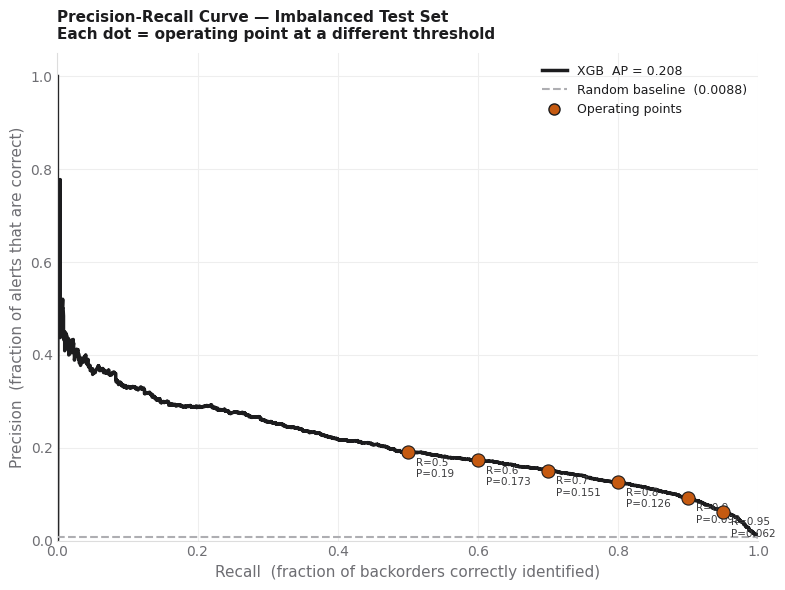


Average Precision (AP) score: 0.2076

Operating point summary:
 Target recall  Achieved recall  Precision  Threshold  FP per TP
          0.50             0.50      0.190      0.998        4.3
          0.60             0.60      0.173      0.995        4.8
          0.70             0.70      0.151      0.989        5.6
          0.80             0.80      0.126      0.967        7.0
          0.90             0.90      0.092      0.846        9.8
          0.95             0.95      0.062      0.384       15.1

Extension 4 complete. Outputs saved.


In [55]:
# ============================================================
# EXTENSION 4: OPERATING-POINT ANALYSIS
# ============================================================
# The paper evaluates at the default 0.5 probability threshold
# and optimises F1, which weights false negatives and false
# positives equally.
#
# In backorder prediction, these errors are NOT equally costly:
# - False Negative (missed backorder): leads to unfulfilled order,
#   lost revenue, missed OTIF targets, damaged customer relationship
# - False Positive (unnecessary alert): analyst reviews the alert,
#   finds no issue, dismisses it — a minor operational cost
#
# Because model predictions are one input to analyst review rather
# than direct triggers for inventory action, false positives are
# cheap. False negatives are expensive.
#
# We evaluate the tuned XGB at multiple probability thresholds
# to show what recall is achievable at different precision levels,
# helping practitioners choose an operating point suited to their
# cost tolerance rather than relying on the default 0.5 threshold.
# ============================================================

print("=" * 60)
print("EXTENSION 4: OPERATING-POINT ANALYSIS")
print("=" * 60)

y_proba_imb = model_rus.predict_proba(X_te_e2_s)[:, 1]

precision_curve, recall_curve, thresholds_curve = precision_recall_curve(
    y_te_e2, y_proba_imb
)
ap_score = average_precision_score(y_te_e2, y_proba_imb)

# ----- Operating point table -----

target_recalls = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]
print(f"\nOperating points on imbalanced test set "
      f"(baseline rate = {y_te_e2.mean()*100:.2f}%):")
print(f"{'Recall':>8}  {'Precision':>10}  {'Threshold':>10}  "
      f"{'FP per TP':>10}")

op_results = []
for tr in target_recalls:
    idx = np.where(recall_curve >= tr)[0]
    if len(idx) > 0:
        i = idx[-1]
        thresh    = thresholds_curve[i] if i < len(thresholds_curve) else 1.0
        prec      = precision_curve[i]
        fp_per_tp = round((1 - prec) / prec, 1) if prec > 0 else float('inf')
        print(f"{recall_curve[i]:>8.3f}  {prec:>10.3f}  "
              f"{thresh:>10.3f}  {fp_per_tp:>10}")
        op_results.append({
            'Target recall':   tr,
            'Achieved recall': round(float(recall_curve[i]), 3),
            'Precision':       round(float(prec), 3),
            'Threshold':       round(float(thresh), 3),
            'FP per TP':       fp_per_tp
        })

op_df = pd.DataFrame(op_results)

# ----- Precision-Recall curve — black and #C55A11 theme -----

fig, ax = plt.subplots(figsize=(8, 6))
# fig.patch.set_facecolor('#F5F5F7')
# ax.set_facecolor('#F5F5F7')

# Main PR curve — black
ax.plot(recall_curve, precision_curve,
        color='#1C1C1E', linewidth=2.5,
        label='XGB  AP = ' + str(round(ap_score, 3)))

# Operating point dots — #C55A11
for row in op_results:
    ax.scatter(row['Achieved recall'], row['Precision'],
               s=90, zorder=5,
               color='#C55A11',
               edgecolors='#1C1C1E',
               linewidths=0.8)
    ax.annotate(
        "R=" + str(row['Achieved recall']) +
        "\nP=" + str(row['Precision']),
        xy=(row['Achieved recall'], row['Precision']),
        xytext=(6, -18),
        textcoords='offset points',
        fontsize=7.5,
        color='#3A3A3C'
    )

# Baseline
ax.axhline(y=y_te_e2.mean(),
           linestyle='--',
           color='#AEAEB2',
           linewidth=1.5,
           label='Random baseline  (' +
                 str(round(y_te_e2.mean(), 4)) + ')')

# Styling
ax.set_xlabel('Recall  (fraction of backorders correctly identified)',
              fontsize=11, color='#6E6E73')
ax.set_ylabel('Precision  (fraction of alerts that are correct)',
              fontsize=11, color='#6E6E73')
ax.set_title('Precision-Recall Curve — Imbalanced Test Set\n'
             'Each dot = operating point at a different threshold',
             fontsize=11, color='#1C1C1E',
             fontweight='bold', pad=10, loc='left')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#DDDDDD')
ax.spines['bottom'].set_color('#DDDDDD')
ax.tick_params(colors='#6E6E73', length=0)
ax.yaxis.grid(True, color='#EEEEEE', linewidth=0.8)
ax.xaxis.grid(True, color='#EEEEEE', linewidth=0.8)
ax.set_axisbelow(True)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)

# Legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_elements = [
    Line2D([0], [0], color='#1C1C1E', linewidth=2.5,
           label='XGB  AP = ' + str(round(ap_score, 3))),
    Line2D([0], [0], color='#AEAEB2', linewidth=1.5,
           linestyle='--',
           label='Random baseline  (' +
                 str(round(y_te_e2.mean(), 4)) + ')'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#C55A11',
           markeredgecolor='#1C1C1E',
           markersize=8,
           label='Operating points'),
]
ax.legend(handles=legend_elements, fontsize=9,
          frameon=False, labelcolor='#1C1C1E',
          loc='upper right')

plt.tight_layout()
plt.savefig('ext4_precision_recall_curve.png',
            dpi=150, bbox_inches='tight',
            facecolor='#F5F5F7')
plt.show()

print("\nAverage Precision (AP) score:", round(ap_score, 4))
print("\nOperating point summary:")
print(op_df.to_string(index=False))

op_df.to_csv('ext4_operating_points.csv', index=False)
print("\nExtension 4 complete. Outputs saved.")